<a href="https://colab.research.google.com/github/enicaking/bluetab-uc3m-project-repo/blob/main/modelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install xgboost
%pip install catboost

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [5]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, jaccard_score, roc_auc_score, precision_score, recall_score, f1_score
from typing import List, Tuple, cast
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from catboost import CatBoostClassifier

from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    roc_auc_score,
    make_scorer,
    fbeta_score
)

from typing import List, Tuple, cast

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from catboost import CatBoostClassifier, Pool

import joblib

In [6]:
import random
random.seed(42)

In [7]:
# NOTE: Comentado para uso local - descomenta si ejecutas en Google Colab
# from google.colab import drive
# drive.mount('/content/drive')
# %cd "/content/drive/MyDrive/YEAR 4 - FALL/Data Science Project/csv_exports"

# Path to data files - desde notebooks/ apunta a content/models/
from pathlib import Path
# En notebooks, __file__ no está definido, así que usamos path relativo
DATA_PATH = Path("../content")

## **Temporal Split Model**
- Temporal split
- Feature Selection (only PCA variables)
- Test all datasets with different proportions

Column timestamp found
Number of unique days: 2

Distribution of transactions per day:
timestamp
2023-01-01    359451
2023-01-02    140549
Name: count, dtype: int64

=== Balance of Class by day ===

Date: 2023-01-01
  Total transactions: 359451
  Class 0 (No fraud): 144377
  Class 1 (Fraud): 215074
  % Fraud: 59.83%

Date: 2023-01-02
  Total transactions: 140549
  Class 0 (No fraud): 139691
  Class 1 (Fraud): 858
  % Fraud: 0.61%
Train date: 2023-01-01
Test date: 2023-01-02
Available PCA variables: 28 of 28
Variables: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']

Shape of df: (500000, 30)

=== Analysis of correlations ===

Paires with correlation >= 0.8: 36

Highly correlated paires:
  V1 <-> V3: 0.8787
  V1 <-> V5: 0.8568
  V1 <-> V7: 0.8627
  V2 <-> V3: 0.8336
  V2 <-> V7: 0.8322
  V3 <-> V5: 0.8567
  V3 <-> V7: 0.8918
  V3 <-> V10: 0.8178
  V

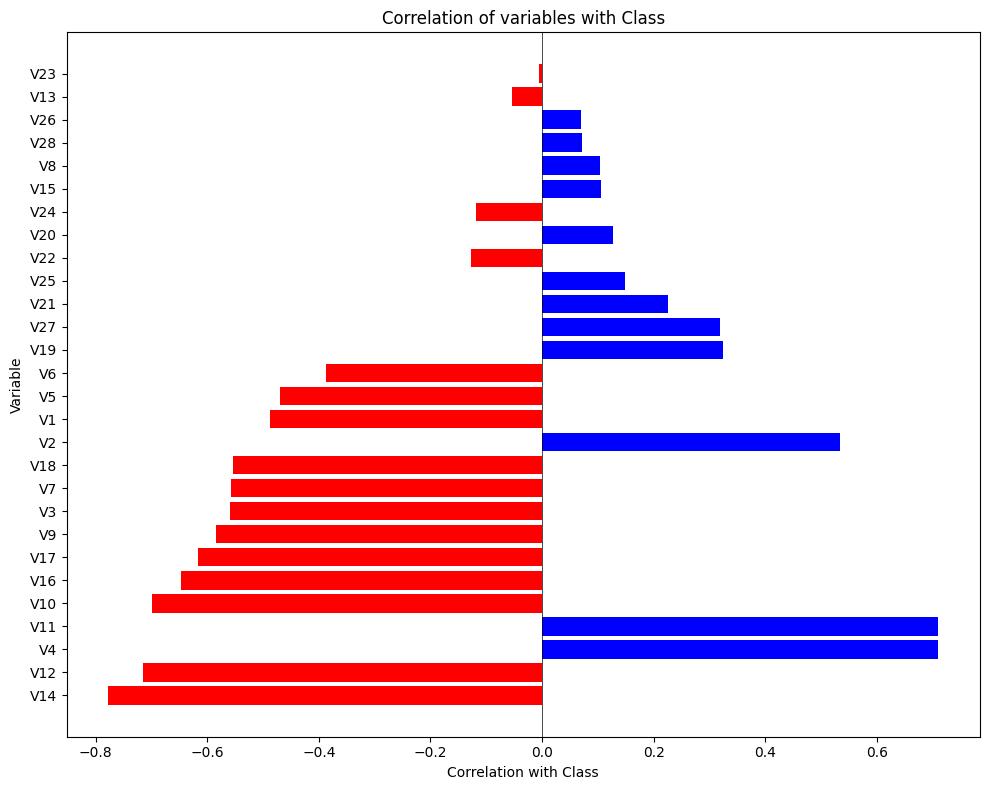

  Removing V1 (corr with Class: 0.4873) vs V3 (corr with Class: 0.5591)
  Removing V2 (corr with Class: 0.5330) vs V3 (corr with Class: 0.5591)
  Removing V5 (corr with Class: 0.4700) vs V3 (corr with Class: 0.5591)
  Removing V7 (corr with Class: 0.5579) vs V3 (corr with Class: 0.5591)
  Removing V3 (corr with Class: 0.5591) vs V10 (corr with Class: 0.6990)
  Removing V10 (corr with Class: 0.6990) vs V4 (corr with Class: 0.7098)
  Removing V11 (corr with Class: 0.7091) vs V4 (corr with Class: 0.7098)
  Removing V4 (corr with Class: 0.7098) vs V12 (corr with Class: 0.7157)
  Removing V9 (corr with Class: 0.5836) vs V12 (corr with Class: 0.7157)
  Removing V12 (corr with Class: 0.7157) vs V14 (corr with Class: 0.7775)
  Removing V16 (corr with Class: 0.6469) vs V14 (corr with Class: 0.7775)
  Removing V17 (corr with Class: 0.6161) vs V14 (corr with Class: 0.7775)

Initial PCA variables: 28
Removed variables: 12
Final variables: 16
Train set - Día: 2023-01-01
  Shape: (359451, 16)
  Clas

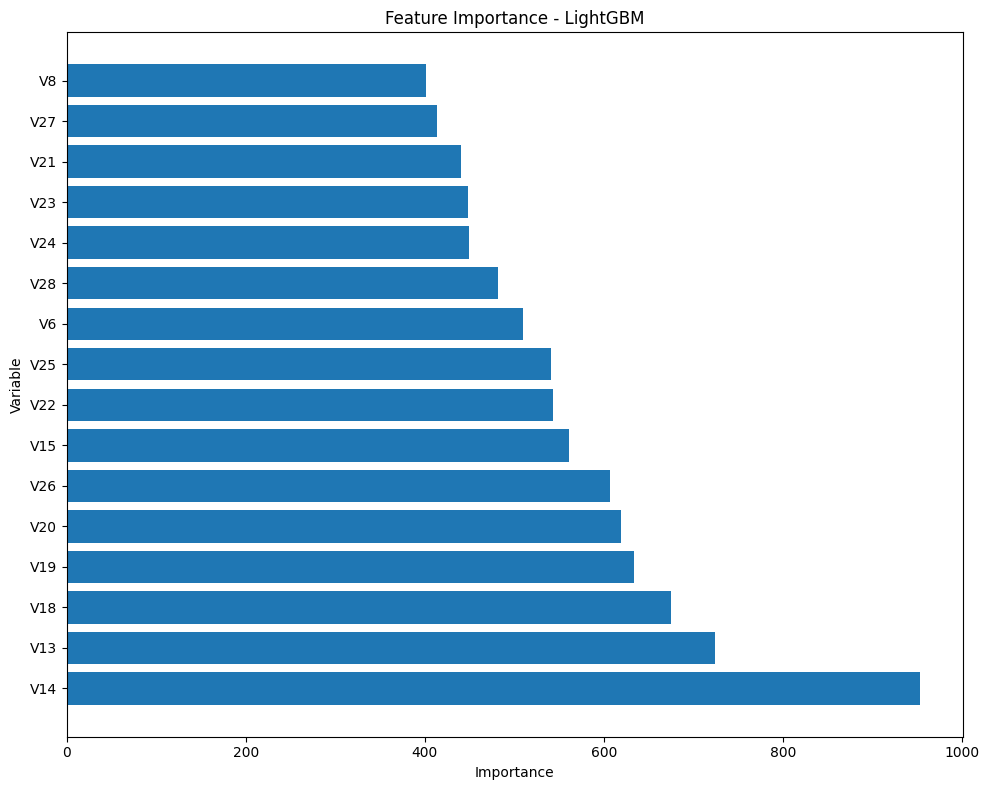

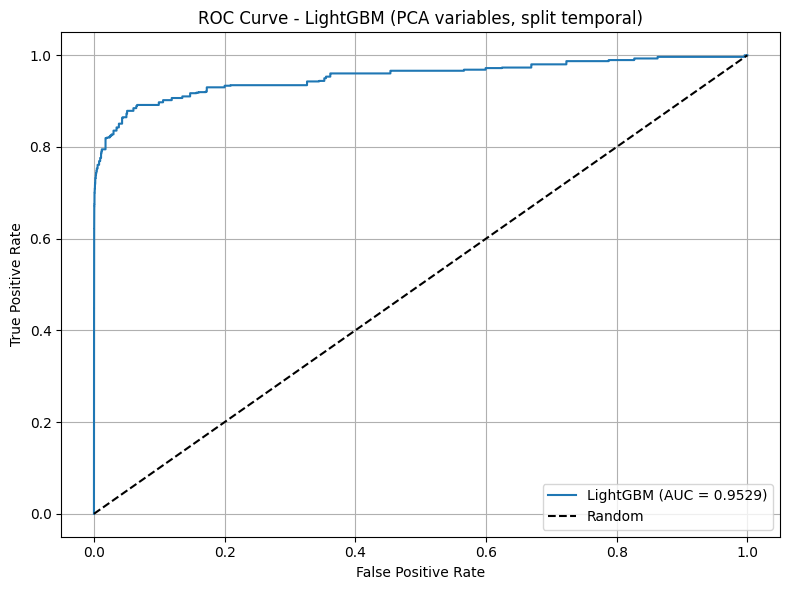

In [8]:
# ==============================================================================
# Feature Selection and Temporal Split
# ==============================================================================

# Path to data files - desde notebooks/ apunta a content/models/
# DATA_PATH se define en Cell 4, pero si no está definido, lo definimos aquí
if 'DATA_PATH' not in globals():
    from pathlib import Path
    DATA_PATH = Path("../content")

# Load dataset from content/
df_full = pd.read_csv(DATA_PATH / "df_exp_50.csv")

# Verifying it contains timestamp
if 'timestamp' in df_full.columns:
    print("Column timestamp found")
    df_work = df_full.copy()
else:
    raise ValueError("The df does not have a timestamp column.")

# =============================
# Treating temporal data
# =============================

ts_series = df_work['timestamp'] if 'timestamp' in df_work.columns else None

if ts_series is not None and bool(ts_series.notna().any()):
    ts_series = pd.to_datetime(ts_series, errors='coerce')
    df_work['timestamp'] = ts_series

    # Extract day
    date_series = ts_series.dt.date
    df_work['date'] = date_series

    # Unique days
    unique_dates = pd.Series(date_series).value_counts().sort_index()
    print(f"Number of unique days: {pd.Series(date_series).nunique()}")
    print("\nDistribution of transactions per day:")
    print(unique_dates.head(10))

    # Verifying class imbalance by day
    print("\n=== Balance of Class by day ===")
    for date in sorted(pd.Series(date_series).dropna().unique())[:5]:
        day_mask = df_work['date'] == date
        day_data = df_work.loc[day_mask]
        class_counts = day_data['Class'].value_counts()
        total_day = len(day_data)
        fraud_count = float(class_counts.get(1, 0))
        print(f"\nDate: {date}")
        print(f"  Total transactions: {total_day}")
        print(f"  Class 0 (No fraud): {class_counts.get(0, 0)}")
        print(f"  Class 1 (Fraud): {int(fraud_count)}")
        if total_day > 0:
            print(f"  % Fraud: {fraud_count / float(total_day) * 100:.2f}%")

    # Train and test split
    sorted_dates = sorted(pd.Series(date_series).dropna().unique())
    if len(sorted_dates) >= 2:
        train_date = sorted_dates[0]  # First day for train
        test_date = sorted_dates[1]   # Second day for test
        print(f"Train date: {train_date}")
        print(f"Test date: {test_date}")
    else:
        print("\nOnly one day in data. Could not make split")
        train_date = sorted_dates[0] if len(sorted_dates) > 0 else None
        test_date = None

# =============================
# 2. Selecting PCA variables
# =============================

pca_vars = [f'V{i}' for i in range(1, 29)]
available_pca_vars = [var for var in pca_vars if var in df_work.columns]
subset_vars = list(available_pca_vars)

print(f"Available PCA variables: {len(available_pca_vars)} of 28")
print(f"Variables: {available_pca_vars}")

if len(available_pca_vars) == 0:
    raise ValueError("No available PCA variables")

# Create df with PCA variables, target and date
cols_to_include = subset_vars + ['Class']
if 'date' in df_work.columns:
    cols_to_include.append('date')

df_pca = df_work[cols_to_include].copy()

pca_only: pd.DataFrame = df_pca.loc[:, subset_vars]
missing_pca = pca_only.isnull().sum()
if missing_pca.sum() > 0:
    print(f"\n Missing values in PCA variables:")
    print(missing_pca[missing_pca > 0])
    # Remove rows with missing values
    df_pca = df_pca.dropna(subset=subset_vars)
    pca_only = df_pca.loc[:, subset_vars]

print(f"\nShape of df: {df_pca.shape}")

# =============================
# 3. Analising correlations
# =============================

print("\n=== Analysis of correlations ===")

corr_matrix: pd.DataFrame = pca_only.corr().abs()

threshold = 0.8
high_corr_pairs: List[Tuple[str, str, float]] = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] >= threshold:
            high_corr_pairs.append((
                str(corr_matrix.columns[i]),
                str(corr_matrix.columns[j]),
                float(corr_matrix.iloc[i, j])
            ))

print(f"\nPaires with correlation >= {threshold}: {len(high_corr_pairs)}")
if len(high_corr_pairs) > 0:
    print("\nHighly correlated paires:")
    for var1, var2, corr_val in high_corr_pairs[:10]:
        print(f"  {var1} <-> {var2}: {corr_val:.4f}")

# =============================
# 4. Correlations with Class
# =============================

print("\n=== Correlations with Class ===")
corr_with_target: pd.DataFrame = df_pca.loc[:, subset_vars + ['Class']].corr()
target_corr = corr_with_target['Class'].drop('Class')
target_corr_abs = target_corr.abs().sort_values(ascending=False)

print(target_corr_abs.to_frame('Correlation_with_Class'))

plt.figure(figsize=(10, 8))
target_corr_sorted = target_corr.reindex(target_corr_abs.index)
target_corr_sorted_values: np.ndarray = target_corr_sorted.to_numpy(dtype=float)

colors = ['red' if x < 0 else 'blue' for x in target_corr_sorted_values]

yticks_positions = np.arange(len(target_corr_sorted_values))
yticks_labels: List[str] = [str(idx) for idx in target_corr_sorted.index]

plt.barh(yticks_positions, target_corr_sorted_values, color=colors)
plt.yticks(yticks_positions, yticks_labels)
plt.xlabel('Correlation with Class')
plt.ylabel('Variable')
plt.title('Correlation of variables with Class')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

# =============================
# 5. Removing correlated variables
# =============================

vars_to_remove: set[str] = set()
vars_considered: set[str] = set(available_pca_vars)

for var1, var2, corr_val in high_corr_pairs:
    if var1 in vars_to_remove or var2 in vars_to_remove:
        continue

    corr1_with_target = abs(float(target_corr[var1]))
    corr2_with_target = abs(float(target_corr[var2]))

    if corr1_with_target >= corr2_with_target:
        vars_to_remove.add(var2)
        print(
            f"  Removing {var2} (corr with Class: {corr2_with_target:.4f}) "
            f"vs {var1} (corr with Class: {corr1_with_target:.4f})"
        )
    else:
        vars_to_remove.add(var1)
        print(
            f"  Removing {var1} (corr with Class: {corr1_with_target:.4f}) "
            f"vs {var2} (corr with Class: {corr2_with_target:.4f})"
        )

final_pca_vars = [var for var in available_pca_vars if var not in vars_to_remove]

print(f"\nInitial PCA variables: {len(available_pca_vars)}")
print(f"Removed variables: {len(vars_to_remove)}")
print(f"Final variables: {len(final_pca_vars)}")

cols_final = final_pca_vars + ['Class']
if 'date' in df_pca.columns:
    cols_final.append('date')
df_pca_final = df_pca[cols_final].copy()

# =============================
# 6. Temporal split
# =============================

if train_date is not None and test_date is not None and 'date' in df_pca_final.columns:
    train_mask = df_pca_final['date'] == train_date
    test_mask = df_pca_final['date'] == test_date

    X_train_temp = df_pca_final.loc[train_mask, final_pca_vars].copy()
    y_train_temp = df_pca_final.loc[train_mask, 'Class'].copy()

    X_test_temp = df_pca_final.loc[test_mask, final_pca_vars].copy()
    y_test_temp = df_pca_final.loc[test_mask, 'Class'].copy()

    print(f"Train set - Día: {train_date}")
    print(f"  Shape: {X_train_temp.shape}")
    print(f"  Clase 0: {(y_train_temp == 0).sum()}")
    print(f"  Clase 1: {(y_train_temp == 1).sum()}")
    if len(y_train_temp) > 0:
        print(f"  % Fraude: {(y_train_temp == 1).sum() / len(y_train_temp) * 100:.2f}%")

    print(f"\nTest set - Día: {test_date}")
    print(f"  Shape: {X_test_temp.shape}")
    print(f"  Clase 0: {(y_test_temp == 0).sum()}")
    print(f"  Clase 1: {(y_test_temp == 1).sum()}")
    if len(y_test_temp) > 0:
        print(f"  % Fraude: {(y_test_temp == 1).sum() / len(y_test_temp) * 100:.2f}%")
    print(y_train_temp.value_counts())
    X_train_res_temp = X_train_temp
    y_train_res_temp = y_train_temp

else:
    print("Couldn't make temporal split")
    X_all = df_pca_final.loc[:, final_pca_vars].copy()
    y_all = df_pca_final.loc[:, 'Class'].copy()

    split_result = train_test_split(
        X_all,
        y_all,
        test_size=0.2,
        random_state=42,
        stratify=y_all,
    )
    X_train_temp, X_test_temp, y_train_temp, y_test_temp = cast(
        Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series],
        split_result,
    )

    print(y_train_temp.value_counts())
    X_train_res_temp = X_train_temp
    y_train_res_temp = y_train_temp

# =============================
# 7. LightGBM training
# =============================

print("\n=== Training with LightGBM===")

lgb_model_pca = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42,
    verbose=-1
)

lgb_model_pca.fit(X_train_res_temp, y_train_res_temp)
y_pred_lgb_pca = lgb_model_pca.predict(X_test_temp)
y_proba_lgb_pca = lgb_model_pca.predict_proba(X_test_temp)[:, 1]

print("\n===== LightGBM (PCA variables, temporal split) =====")
print(classification_report(y_test_temp, y_pred_lgb_pca))
print(f"ROC AUC: {roc_auc_score(y_test_temp, y_proba_lgb_pca):.4f}")

cm = confusion_matrix(y_test_temp, y_pred_lgb_pca)
print("\nMatriz de confusión:")
print(cm)
feature_importance_pca = pd.Series(
    lgb_model_pca.feature_importances_,
    index=final_pca_vars
).sort_values(ascending=False)

print("\n=== Feature Importance (Top 10) ===")
print(feature_importance_pca.head(10))

plt.figure(figsize=(10, 8))
fi_values: np.ndarray = feature_importance_pca.to_numpy(dtype=float)
fi_positions = np.arange(len(fi_values))
fi_labels: List[str] = [str(idx) for idx in feature_importance_pca.index]

plt.barh(fi_positions, fi_values)
plt.yticks(fi_positions, fi_labels)
plt.xlabel('Importance')
plt.ylabel('Variable')
plt.title('Feature Importance - LightGBM')
plt.tight_layout()
plt.show()

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test_temp, y_proba_lgb_pca)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'LightGBM (AUC = {roc_auc_score(y_test_temp, y_proba_lgb_pca):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM (PCA variables, split temporal)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
# ============================================================================
# Detailed analysis with appropriate metrics for extreme imbalance
# ============================================================================

def eval_desbalanceado_detallado1(df_in: pd.DataFrame, name: str) -> dict:
    """
    - Temporal split: Day 1 / Day 2
    - Uses only PCA variables (V1-V28)
    - Removes highly correlated PCA variables, keeping the one most correlated
    with the target.
    Returns a dictionary with key comparison metrics
    """
    print(f"\n{'='*60}")
    print(f"Detailed Analysis: {name}")
    print(f"{'='*60}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # Timestamp -> date
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No timestamp found; skipping.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Initial selection of PCA variables (V1-V28)
    # ---------------------------------------------------------------------
    pca_vars = [f"V{i}" for i in range(1, 29)]
    available_pca_vars = [v for v in pca_vars if v in df_local.columns]
    if not available_pca_vars:
        print("No V1-V28 variables found; skipping.")
        return {}

    print(f"Available PCA variables: {len(available_pca_vars)} -> {available_pca_vars}")

    # Remove rows with NaN in PCA vars or Class
    df_local = df_local.dropna(subset=available_pca_vars + ['Class'])

    # ---------------------------------------------------------------------
    # 2) Temporal Split (Day 1 for train, Day 2 for test)
    # ---------------------------------------------------------------------
    dates = sorted([d for d in df_local['date'].dropna().unique()])
    if len(dates) < 2:
        print("Only one day found; evaluation skipped.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    train_df = df_local.loc[df_local['date'] == train_date].copy()
    test_df = df_local.loc[df_local['date'] == test_date].copy()

    # ---------------------------------------------------------------------
    # 3) Analysis of correlations between PCA vars and with Target
    # ---------------------------------------------------------------------
    print("\n=== PCA Variable Correlation Analysis ===")
    pca_only_train: pd.DataFrame = train_df.loc[:, available_pca_vars]

    # Absolute correlation matrix between PCA vars
    corr_matrix: pd.DataFrame = pca_only_train.corr().abs()

    # Pairs of highly correlated variables
    threshold_corr = 0.8
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] >= threshold_corr:
                high_corr_pairs.append(
                    (corr_matrix.columns[i], corr_matrix.columns[j], float(corr_matrix.iloc[i, j]))
                )
    print(f"Variable pairs with correlation >= {threshold_corr}: {len(high_corr_pairs)}")

    # Correlations with Target (Class) in TRAIN
    corr_with_target = train_df[available_pca_vars + ['Class']].corr()
    target_corr = corr_with_target['Class'].drop('Class')

    print("\nCorrelations with Class (sorted by |correlation|):")
    print(target_corr.abs().sort_values(ascending=False).to_frame("Correlation_with_Class"))

    # ---------------------------------------------------------------------
    # 4) Remove highly correlated PCA variables
    # ---------------------------------------------------------------------
    print("\n=== Removing Highly Correlated PCA Variables ===")
    vars_to_remove: set[str] = set()

    for var1, var2, corr_val in high_corr_pairs:
        # If one was already removed in a previous step, skip pair
        if var1 in vars_to_remove or var2 in vars_to_remove:
            continue

        corr1_with_target = abs(float(target_corr[var1]))
        corr2_with_target = abs(float(target_corr[var2]))

        if corr1_with_target >= corr2_with_target:
            # Keep var1, remove var2
            vars_to_remove.add(var2)
            print(
                f"  Removing {var2} (|corr target|={corr2_with_target:.4f}) "
                f"vs {var1} (|corr target|={corr1_with_target:.4f})  [corr {corr_val:.4f}]"
            )
        else:
            vars_to_remove.add(var1)
            print(
                f"  Removing {var1} (|corr target|={corr1_with_target:.4f}) "
                f"vs {var2} (|corr target|={corr2_with_target:.4f})  [corr {corr_val:.4f}]"
            )

    final_pca_vars = [v for v in available_pca_vars if v not in vars_to_remove]

    print(f"\nInitial PCA variables: {len(available_pca_vars)}")
    print(f"Variables removed due to high correlation: {len(vars_to_remove)} -> {sorted(list(vars_to_remove))}")
    print(f"Final PCA variables used: {len(final_pca_vars)} -> {final_pca_vars}")

    if not final_pca_vars:
        print("No PCA variables left after filtering; skipping.")
        return {}

    # ---------------------------------------------------------------------
    # 5) Drop duplicates using ONLY final PCA vars
    # ---------------------------------------------------------------------
    train_df = train_df.drop_duplicates(subset=final_pca_vars)
    test_df = test_df.drop_duplicates(subset=final_pca_vars)

    X_train = train_df[final_pca_vars]
    y_train = train_df['Class']
    X_test = test_df[final_pca_vars]
    y_test = test_df['Class']

    print(f"\nShape train: {X_train.shape} | Shape test: {X_test.shape}")

    # ---------------------------------------------------------------------
    # 6) Train LightGBM model
    # ---------------------------------------------------------------------
    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        random_state=42,
        verbose=-1,
    )
    model.fit(X_train, y_train)

    # Prediction probabilities
    y_proba = model.predict_proba(X_test)[:, 1]

    # ---------------------------------------------------------------------
    # 7) Confusion Matrix with threshold 0.5
    # ---------------------------------------------------------------------
    y_pred_05 = (y_proba >= 0.5).astype(int)
    cm_05 = confusion_matrix(y_test, y_pred_05)

    print("\n--- Confusion Matrix (threshold=0.5) ---")
    print("                Predicted")
    print("              No Fraud   Fraud")
    print(f"Actual No Fraud   {cm_05[0,0]:6d}  {cm_05[0,1]:6d}")
    print(f"       Fraud       {cm_05[1,0]:6d}  {cm_05[1,1]:6d}")

    # Metrics per class with threshold 0.5
    tn, fp, fn, tp = cm_05.ravel()
    recall_fraude_05 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precision_fraude_05 = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall_no_fraude_05 = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    # F1 Score
    f1_fraude_05 = (
        2 * (precision_fraude_05 * recall_fraude_05) / (precision_fraude_05 + recall_fraude_05)
        if (precision_fraude_05 + recall_fraude_05) > 0
        else 0.0
    )

    # F2 Score (Recall weighted x2 vs Precision)
    f2_fraude_05 = (
        5 * (precision_fraude_05 * recall_fraude_05) / ((4 * precision_fraude_05) + recall_fraude_05)
        if ((4 * precision_fraude_05) + recall_fraude_05) > 0
        else 0.0
    )

    print(f"\n--- Metrics with threshold=0.5 ---")
    print(f"Fraud Recall:      {recall_fraude_05:.4f} ({tp}/{tp+fn} frauds detected)")
    print(f"Fraud Precision:   {precision_fraude_05:.4f} ({tp}/{tp+fp} alerts are fraud)")
    print(f"No Fraud Recall:   {recall_no_fraude_05:.4f}")
    print(f"Fraud F1:          {f1_fraude_05:.4f}")
    print(f"Fraud F2:          {f2_fraude_05:.4f} (Prioritizes Recall)")

    # ---------------------------------------------------------------------
    # 8) Precision-Recall Curve and AUC-PR
    # ---------------------------------------------------------------------
    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"\n--- Precision-Recall Curve ---")
    print(f"AUC-PR: {auc_pr:.4f} (more informative than ROC-AUC for extreme imbalance)")
    print(f"ROC-AUC: {roc_auc:.4f}")

    # ---------------------------------------------------------------------
    # 9) Optimal Threshold (Maximize F2 for Fraud)
    # ---------------------------------------------------------------------
    scores_list = []

    for thresh in thresholds_pr:
        y_pred_th = (y_proba >= thresh).astype(int)
        cm_th = confusion_matrix(y_test, y_pred_th)
        if cm_th.shape == (2, 2):
            tn_th, fp_th, fn_th, tp_th = cm_th.ravel()
            prec_th = tp_th / (tp_th + fp_th) if (tp_th + fp_th) > 0 else 0.0
            rec_th = tp_th / (tp_th + fn_th) if (tp_th + fn_th) > 0 else 0.0

            f1_th = (
                2 * (prec_th * rec_th) / (prec_th + rec_th)
                if (prec_th + rec_th) > 0 else 0.0
            )

            f2_th = (
                5 * (prec_th * rec_th) / ((4 * prec_th) + rec_th)
                if ((4 * prec_th) + rec_th) > 0 else 0.0
            )

            scores_list.append((thresh, tp_th, fp_th, fn_th, prec_th, rec_th, f1_th, f2_th))

    # Initialization for optimal F2
    best_thresh_f2, best_tp_f2, best_fp_f2, best_fn_f2, best_prec_f2, best_rec_f2, best_f1_score, best_f2_score = (
        0.5, 0, 0, 0, 0.0, 0.0, 0.0, 0.0
    )

    if scores_list:
        best_row_f2 = max(scores_list, key=lambda x: x[7])
        best_thresh_f2, best_tp_f2, best_fp_f2, best_fn_f2, best_prec_f2, best_rec_f2, best_f1_score, best_f2_score = best_row_f2

        # --- F2 Optimal Report ---
        print(f"\n--- Optimal Threshold (maximizes F2 - Recommended for Fraud) ---")
        print(f"Fraud F1: {best_f1_score:.4f}")
        print(f"Fraud F2: {best_f2_score:.4f}")
        print(f"Precision: {best_prec_f2:.4f}")
        print(f"Recall: {best_rec_f2:.4f}")
        print(f"Threshold: {best_thresh_f2:.4f}")
        print(f"Detected Frauds: {best_tp_f2}/{best_tp_f2 + best_fn_f2} (Recall: {best_rec_f2:.4f})")
        print(f"False Positives: {best_fp_f2}")

    # ---------------------------------------------------------------------
    # 10) Plots
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'Precision-Recall (AUC={auc_pr:.4f})', linewidth=2)
    plt.xlabel('Recall (Fraud)', fontsize=12)
    plt.ylabel('Precision (Fraud)', fontsize=12)
    plt.title(f'Precision-Recall Curve - {name}', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.hist(y_proba[y_test == 0], bins=50, alpha=0.5, label='No Fraud', density=True)
    plt.hist(y_proba[y_test == 1], bins=50, alpha=0.5, label='Fraud', density=True)
    plt.axvline(x=0.5, color='red', linestyle='--', label='Threshold 0.5')
    if scores_list:
        plt.axvline(
            x=best_thresh_f2,
            color='blue',
            linestyle=':',
            linewidth=2,
            label=f'Thresh F2 ({best_thresh_f2:.3f})'
        )
    plt.xlabel('Predicted Probability (Fraud)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.title(f'Probability Distribution - {name}', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nTest distribution: {y_test.value_counts().to_dict()}")
    print(f"Frauds in test: {y_test.sum()} ({y_test.sum()/len(y_test)*100:.2f}%)")

    # ---------------------------------------------------------------------
    # 11) Return metrics for comparison
    # ---------------------------------------------------------------------
    return {
        'dataset': name,
        'roc_auc': roc_auc,
        'auc_pr': auc_pr,

        # Metrics at 0.5
        'f1_fraude_05': f1_fraude_05,
        'f2_fraude_05': f2_fraude_05,
        'precision_fraude_05': precision_fraude_05,
        'recall_fraude_05': recall_fraude_05,

        # Optimal Metrics (F2)
        'best_thresh_f2': best_thresh_f2,
        'f1_fraude_opt': best_f1_score,
        'f2_fraude_opt': best_f2_score,
        'precision_at_f2_opt': best_prec_f2,
        'recall_at_f2_opt': best_rec_f2,

        'fraudes_totales': int(y_test.sum()),
    }


Detailed Analysis: df_exp_50
Available PCA variables: 28 -> ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== PCA Variable Correlation Analysis ===
Variable pairs with correlation >= 0.8: 38

Correlations with Class (sorted by |correlation|):
     Correlation_with_Class
V14                0.727365
V4                 0.660910
V12                0.659812
V10                0.641598
V11                0.639055
V16                0.585987
V17                0.553310
V3                 0.535643
V9                 0.524988
V7                 0.489584
V18                0.485988
V2                 0.483804
V1                 0.417942
V5                 0.391260
V6                 0.387694
V19                0.302776
V27                0.285747
V21                0.198473
V24                0.133044
V20   

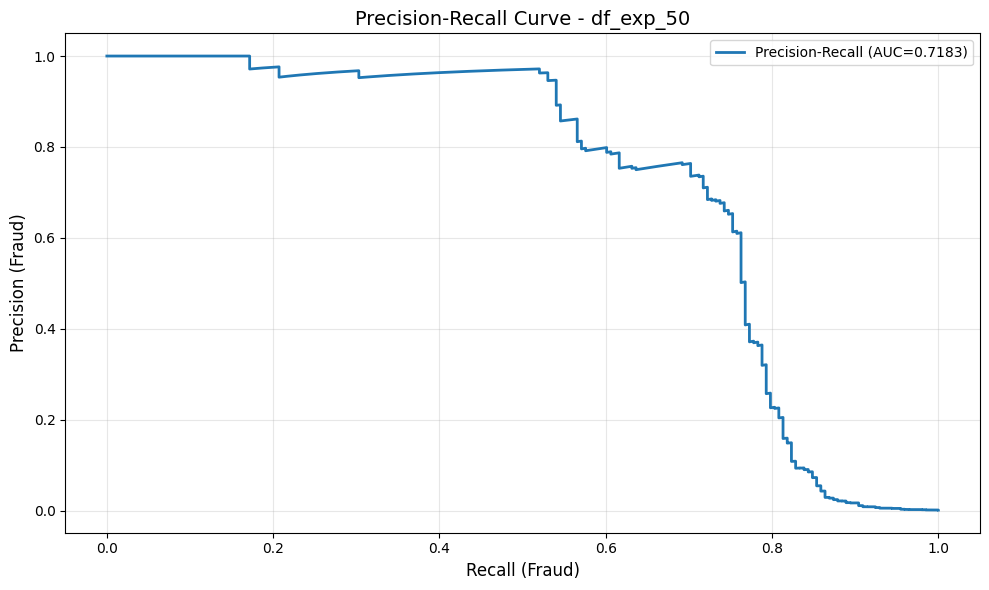

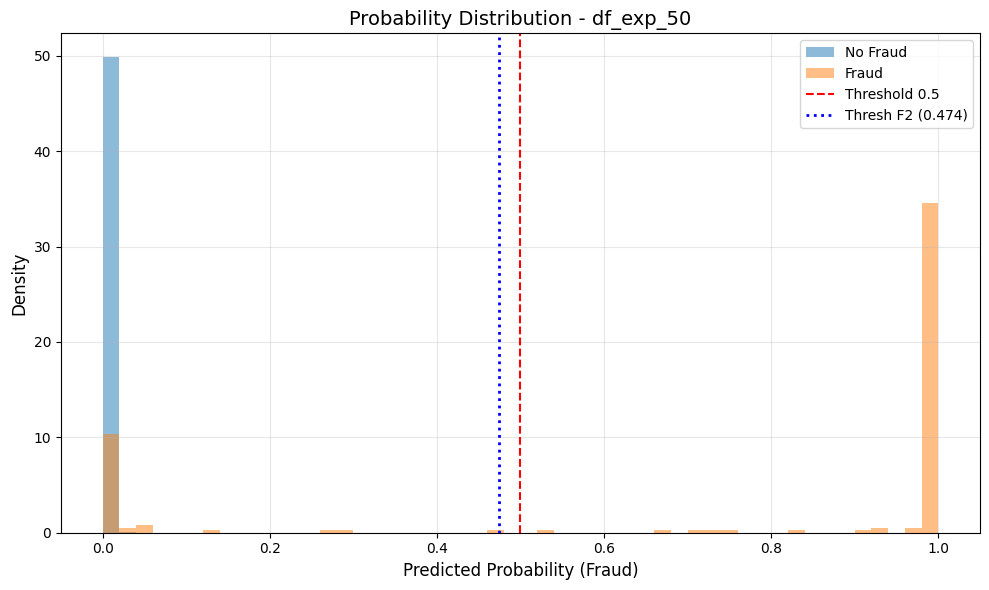


Test distribution: {0: 135134, 1: 198}
Frauds in test: 198 (0.15%)

Detailed Analysis: df_exp_random
Available PCA variables: 28 -> ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== PCA Variable Correlation Analysis ===
Variable pairs with correlation >= 0.8: 0

Correlations with Class (sorted by |correlation|):
     Correlation_with_Class
V14                0.576213
V17                0.559115
V12                0.482525
V3                 0.441834
V10                0.425128
V16                0.402848
V7                 0.371840
V11                0.315465
V4                 0.277835
V18                0.259296
V1                 0.225838
V5                 0.218690
V9                 0.201004
V2                 0.196092
V21                0.148990
V27                0.122119
V6                 

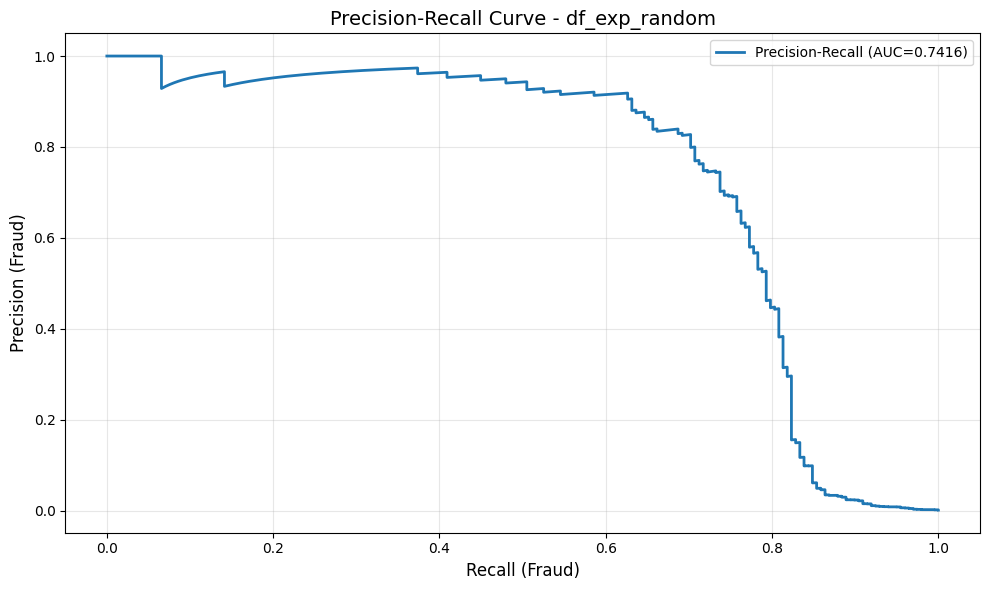

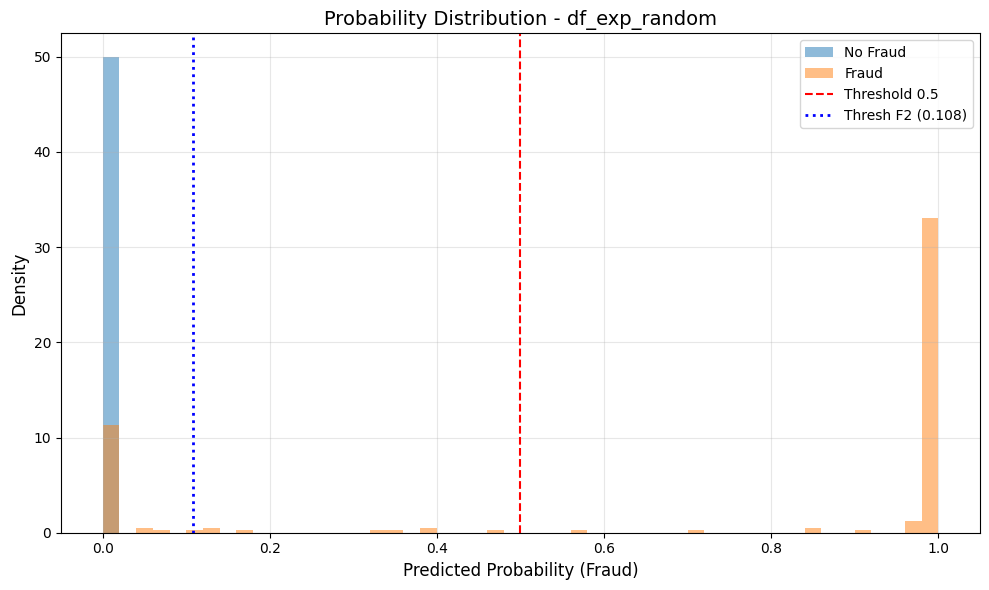


Test distribution: {0: 135134, 1: 198}
Frauds in test: 198 (0.15%)

Detailed Analysis: df_exp_63
Available PCA variables: 28 -> ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== PCA Variable Correlation Analysis ===
Variable pairs with correlation >= 0.8: 38

Correlations with Class (sorted by |correlation|):
     Correlation_with_Class
V14                0.772652
V12                0.709711
V4                 0.698746
V10                0.691330
V11                0.683162
V16                0.638590
V17                0.609516
V3                 0.589876
V9                 0.565319
V7                 0.542446
V18                0.535189
V2                 0.526138
V1                 0.464362
V5                 0.436636
V6                 0.409015
V19                0.330211
V27                0.3

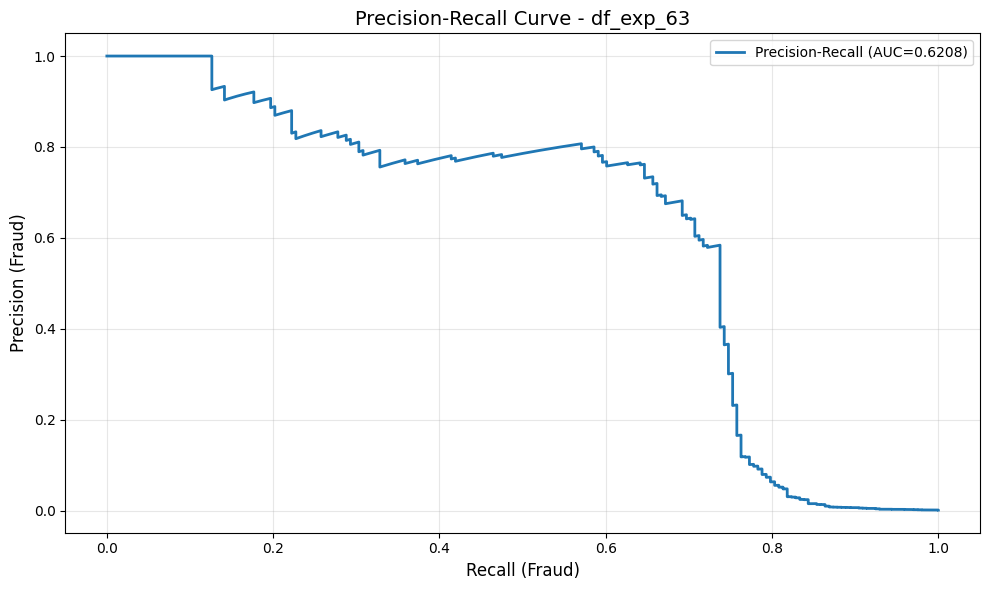

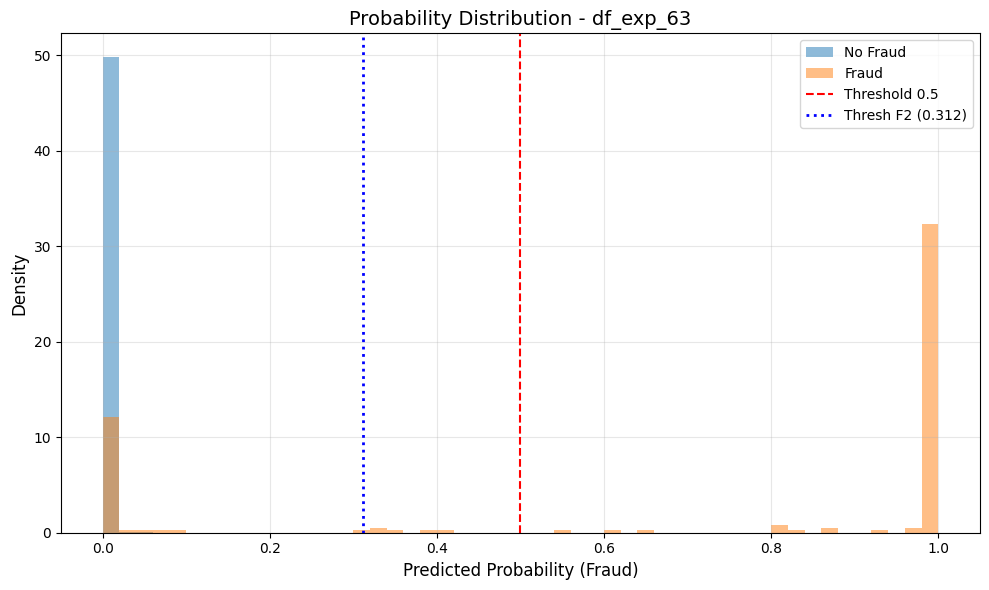


Test distribution: {0: 135134, 1: 198}
Frauds in test: 198 (0.15%)

Detailed Analysis: df_exp_same_prop
Available PCA variables: 28 -> ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== PCA Variable Correlation Analysis ===
Variable pairs with correlation >= 0.8: 0

Correlations with Class (sorted by |correlation|):
     Correlation_with_Class
V14                0.575789
V17                0.556847
V12                0.483456
V3                 0.438228
V10                0.423072
V16                0.403500
V7                 0.368359
V11                0.314122
V4                 0.275406
V18                0.259000
V1                 0.225918
V5                 0.217913
V9                 0.197275
V2                 0.194694
V21                0.154926
V27                0.119519
V6              

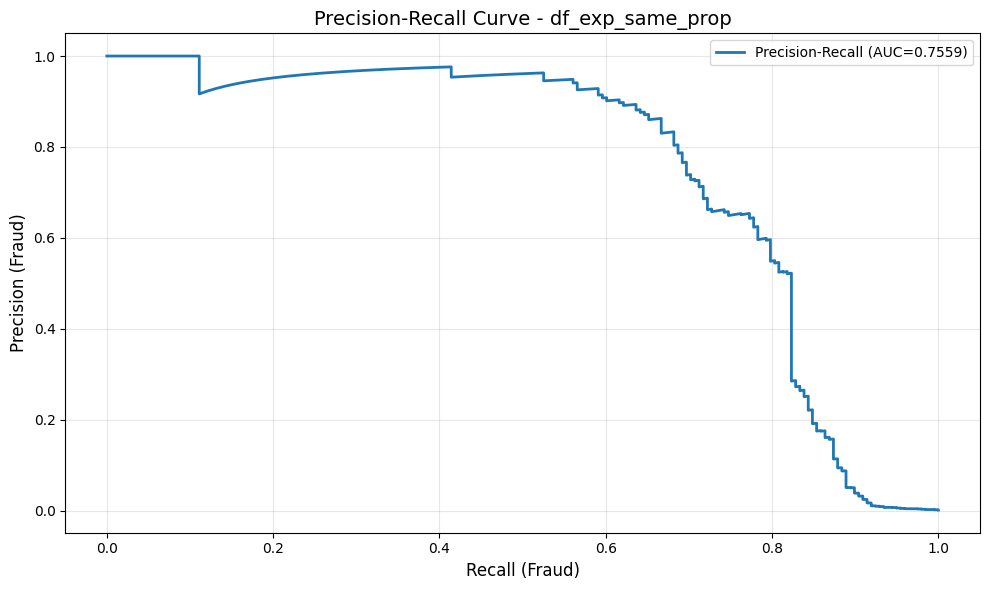

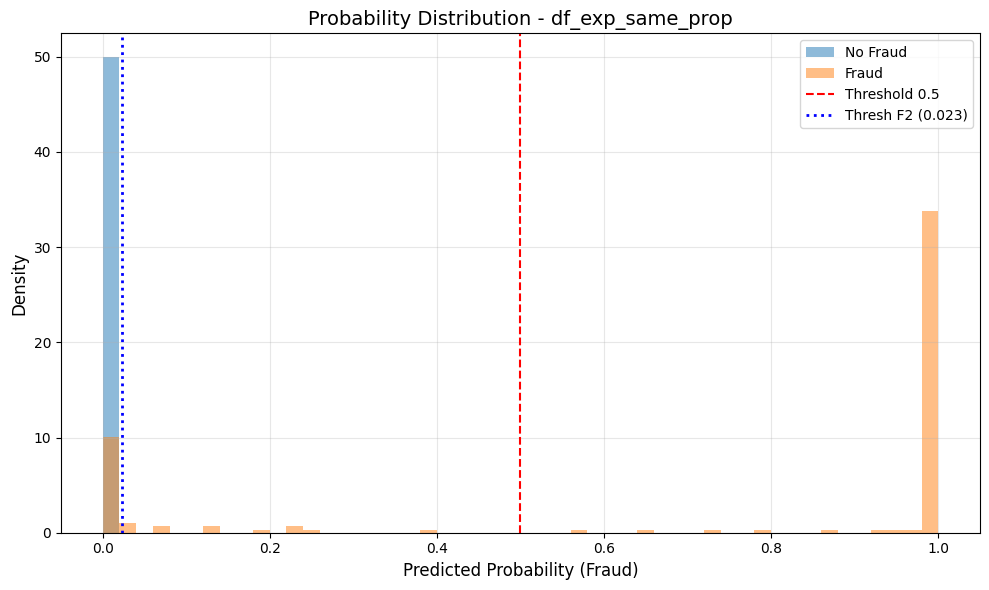


Test distribution: {0: 135134, 1: 198}
Frauds in test: 198 (0.15%)

FINAL COMPARATIVE TABLE (Sorted by F2-Score)
         dataset  f1_fraude_opt  f2_fraude_opt  precision_at_f2_opt  recall_at_f2_opt   auc_pr  roc_auc  best_thresh_f2
df_exp_same_prop       0.682505       0.747398             0.596226          0.797980 0.755879 0.971842        0.022993
   df_exp_random       0.722892       0.743310             0.691244          0.757576 0.741586 0.968971        0.108057
       df_exp_50       0.699531       0.730392             0.653509          0.752525 0.718251 0.955187        0.474460
       df_exp_63       0.651786       0.700576             0.584000          0.737374 0.620800 0.937718        0.311567


In [10]:
# ============================================================================
# Mass evaluation execution on experimental datasets
# ============================================================================

# Path to data files - desde notebooks/ apunta a content/models/
# DATA_PATH should be defined in a previous cell (Cell 4 or Cell 6)
# If not defined, use relative path
if 'DATA_PATH' not in globals():
    from pathlib import Path
    DATA_PATH = Path(__file__).parent.parent / "content"  if '__file__' in globals() else Path("../content")

# 1. Define the list of tuples (dataframe, name)
#df_exp_50 = pd.read_csv("df_exp_50.csv")
#df_exp_random = pd.read_csv("df_exp_random.csv")
#df_exp_63 = pd.read_csv("df_exp_63.csv")
#df_exp_same_prop = pd.read_csv("df_exp_same_prop.csv")
df_exp_50 = pd.read_csv(DATA_PATH / "df_exp_50.csv")
df_exp_random = pd.read_csv(DATA_PATH / "df_exp_random.csv")
df_exp_63 = pd.read_csv(DATA_PATH / "df_exp_63.csv")
df_exp_same_prop = pd.read_csv(DATA_PATH / "df_exp_same_prop.csv")

datasets_to_evaluate = [
    (df_exp_50, 'df_exp_50'),
    (df_exp_random, 'df_exp_random'),
    (df_exp_63, 'df_exp_63'),
    (df_exp_same_prop, 'df_exp_same_prop')
]

# 2. List to accumulate results
results_list = []

# 3. Execution loop
for df_dataset, name_dataset in datasets_to_evaluate:
    try:
        # Run the function with F2 included
        metrics = eval_desbalanceado_detallado1(df_dataset, name_dataset)

        # If the function returns data (not empty due to error), save it
        if metrics:
            results_list.append(metrics)

    except Exception as e:
        print(f"Error processing {name_dataset}: {e}")

# ============================================================================
# Final Comparative Summary
# ============================================================================

if results_list:
    df_results = pd.DataFrame(results_list)

    # Key columns to show in the summary (prioritizing F2 and Recall)
    cols_to_show = [
        'dataset',
        'f1_fraude_opt',
        'f2_fraude_opt',
        'precision_at_f2_opt',
        'recall_at_f2_opt',
        'auc_pr',
        'roc_auc',
        'best_thresh_f2'
    ]

    # Filter only columns that exist (for safety)
    final_cols = [c for c in cols_to_show if c in df_results.columns]

    print("\n" + "="*80)
    print("FINAL COMPARATIVE TABLE (Sorted by F2-Score)")
    print("="*80)

    # Sort by F2 Score descending
    summary_sorted = df_results[final_cols].sort_values(by='f2_fraude_opt', ascending=False)

    # Print
    print(summary_sorted.to_string(index=False))

else:
    print("No results generated to show.")

We observe that the balanced dfs contain correlation, which didn't make sense since the variables are supposed to come from a PCA, thus we study correlation for Class = 1 (in the preprocessing.ipynb file) and create new datasets taking into account this correlation.

Now, we do the same with all the datasets to compare them but with Random Forest instead of LightGBM to see if it performs better.

## Evaluating all datasets with Random Forest

In [11]:
# ============================================================================
# Detailed analysis with Random Forest for extreme imbalance
# ============================================================================
def eval_desbalanceado_rf(df_in: pd.DataFrame, name: str) -> dict:
    print(f"\n{'='*60}")
    print(f"Detailed analysis (Random Forest): {name}")
    print(f"{'='*60}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # Timestamp -> date
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No timestamp found; skipping.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Initial selection of PCA variables (V1-V28)
    # ---------------------------------------------------------------------
    pca_vars = [f"V{i}" for i in range(1, 29)]
    available_pca_vars = [v for v in pca_vars if v in df_local.columns]
    if not available_pca_vars:
        print("No V1-V28 variables found; skipping.")
        return {}

    print(f"Available PCA variables: {len(available_pca_vars)} -> {available_pca_vars}")

    # Remove rows with NaN
    df_local = df_local.dropna(subset=available_pca_vars + ['Class'])

    # ---------------------------------------------------------------------
    # 2) Temporal Split (Day 1 train, Day 2 test)
    # ---------------------------------------------------------------------
    dates = sorted([d for d in df_local['date'].dropna().unique()])
    if len(dates) < 2:
        print("Only one day found; evaluation skipped.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    train_df = df_local.loc[df_local['date'] == train_date].copy()
    test_df = df_local.loc[df_local['date'] == test_date].copy()

    # ---------------------------------------------------------------------
    # 3) Correlation Analysis
    # ---------------------------------------------------------------------
    print("\n=== PCA Variable Correlation Analysis ===")
    pca_only_train = train_df.loc[:, available_pca_vars]
    corr_matrix = pca_only_train.corr().abs()

    threshold_corr = 0.8
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i + 1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] >= threshold_corr:
                high_corr_pairs.append(
                    (corr_matrix.columns[i], corr_matrix.columns[j], float(corr_matrix.iloc[i, j]))
                )
    print(f"Pairs with correlation >= {threshold_corr}: {len(high_corr_pairs)}")

    # Correlations with the target in TRAIN
    corr_with_target = train_df[available_pca_vars + ['Class']].corr()
    target_corr = corr_with_target['Class'].drop('Class')

    # ---------------------------------------------------------------------
    # 4) Remove highly correlated PCA variables
    # ---------------------------------------------------------------------
    vars_to_remove = set()

    for var1, var2, corr_val in high_corr_pairs:
        if var1 in vars_to_remove or var2 in vars_to_remove:
            continue

        c1 = abs(float(target_corr[var1]))
        c2 = abs(float(target_corr[var2]))

        if c1 >= c2:
            vars_to_remove.add(var2)
        else:
            vars_to_remove.add(var1)

    final_pca_vars = [v for v in available_pca_vars if v not in vars_to_remove]
    print(f"Variables removed: {len(vars_to_remove)}")
    print(f"Final variables: {len(final_pca_vars)}")

    if not final_pca_vars:
        return {}

    # ---------------------------------------------------------------------
    # 5) Deduplicate and prepare X, y
    # ---------------------------------------------------------------------
    train_df = train_df.drop_duplicates(subset=final_pca_vars)
    test_df = test_df.drop_duplicates(subset=final_pca_vars)

    X_train = train_df[final_pca_vars]
    y_train = train_df['Class']
    X_test = test_df[final_pca_vars]
    y_test = test_df['Class']

    # ---------------------------------------------------------------------
    # 6) Train Random Forest
    # ---------------------------------------------------------------------
    # class_weight='balanced' is vital here to replace scale_pos_weight logic
    model = RandomForestClassifier(
        n_estimators=200,
        criterion='gini',
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )

    model.fit(X_train, y_train)

    # Predictions (probability of class 1)
    y_proba = model.predict_proba(X_test)[:, 1]

    # ---------------------------------------------------------------------
    # 7) Standard Metrics (Threshold 0.5)
    # ---------------------------------------------------------------------
    y_pred_05 = (y_proba >= 0.5).astype(int)
    cm_05 = confusion_matrix(y_test, y_pred_05)

    tn, fp, fn, tp = cm_05.ravel()

    rec_05 = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec_05 = tp / (tp + fp) if (tp + fp) > 0 else 0.0

    f1_05 = 2 * (prec_05 * rec_05) / (prec_05 + rec_05) if (prec_05 + rec_05) > 0 else 0.0

    # F2 Score
    f2_05 = 5 * (prec_05 * rec_05) / ((4 * prec_05) + rec_05) if ((4 * prec_05) + rec_05) > 0 else 0.0

    print("\n--- Confusion Matrix (RF at 0.5) ---")
    print(f"TN: {tn} | FP: {fp}")
    print(f"FN: {fn} | TP: {tp}")
    print(f"F2 Score: {f2_05:.4f}")

    # ---------------------------------------------------------------------
    # 8) Curves and AUC
    # ---------------------------------------------------------------------
    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"AUC-PR: {auc_pr:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    # ---------------------------------------------------------------------
    # 9) Optimal Threshold (Maximize F2)
    # ---------------------------------------------------------------------
    scores_list = []
    for prec_th, rec_th, thresh in zip(precision_arr[:-1], recall_arr[:-1], thresholds_pr):

        # Manually calculate F2 for each point on the curve
        denom = (4 * prec_th) + rec_th
        if denom > 0:
            f2_val = 5 * (prec_th * rec_th) / denom
        else:
            f2_val = 0.0

        scores_list.append((thresh, prec_th, rec_th, f2_val))

    # Initialize
    best_thresh_f2 = 0.5
    best_f2_score = 0.0
    best_rec_f2 = 0.0
    best_prec_f2 = 0.0

    if scores_list:
        # Tuple: (thresh, prec, rec, f2) -> Index 3 is F2
        best_row = max(scores_list, key=lambda x: x[3])
        best_thresh_f2, best_prec_f2, best_rec_f2, best_f2_score = best_row

        # Recalculate TP/FP for exact reporting with that threshold
        y_pred_opt = (y_proba >= best_thresh_f2).astype(int)
        cm_opt = confusion_matrix(y_test, y_pred_opt)
        tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

        print(f"\n--- Optimal Threshold RF (Max F2) ---")
        print(f"Threshold: {best_thresh_f2:.4f}")
        print(f"F2 Score:  {best_f2_score:.4f}")
        print(f"Recall:    {best_rec_f2:.4f} (TP: {tp_opt})")
        print(f"Precision: {best_prec_f2:.4f} (FP: {fp_opt})")

    # ---------------------------------------------------------------------
    # 10) Plots
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'RF PR Curve (AUC={auc_pr:.4f})', color='green', linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall - Random Forest - {name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.hist(y_proba[y_test == 0], bins=50, alpha=0.5, label='No Fraud', density=True, color='skyblue')
    plt.hist(y_proba[y_test == 1], bins=50, alpha=0.5, label='Fraud', density=True, color='orange')
    plt.axvline(x=0.5, color='red', linestyle='--', label='Thresh 0.5')
    plt.axvline(x=best_thresh_f2, color='green', linestyle=':', linewidth=2, label=f'Best F2 ({best_thresh_f2:.3f})')
    plt.xlabel('Probability (RF)')
    plt.title(f'Probability Distribution - {name}')
    plt.legend()
    plt.show()

    return {
        'dataset': name,
        'model': 'RandomForest',
        'roc_auc': roc_auc,
        'auc_pr': auc_pr,
        'f2_fraude_05': f2_05,
        'best_thresh_f2': best_thresh_f2,
        'f2_fraude_opt': best_f2_score,
        'recall_at_f2_opt': best_rec_f2,
        'fraudes_totales': int(y_test.sum())
    }


Detailed analysis (Random Forest): df_exp_50
Available PCA variables: 28 -> ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== PCA Variable Correlation Analysis ===
Pairs with correlation >= 0.8: 38
Variables removed: 12
Final variables: 16

--- Confusion Matrix (RF at 0.5) ---
TN: 135102 | FP: 32
FN: 69 | TP: 129
F2 Score: 0.6768
AUC-PR: 0.6882
ROC-AUC: 0.9680

--- Optimal Threshold RF (Max F2) ---
Threshold: 0.3613
F2 Score:  0.7280
Recall:    0.7273 (TP: 144)
Precision: 0.7310 (FP: 53)


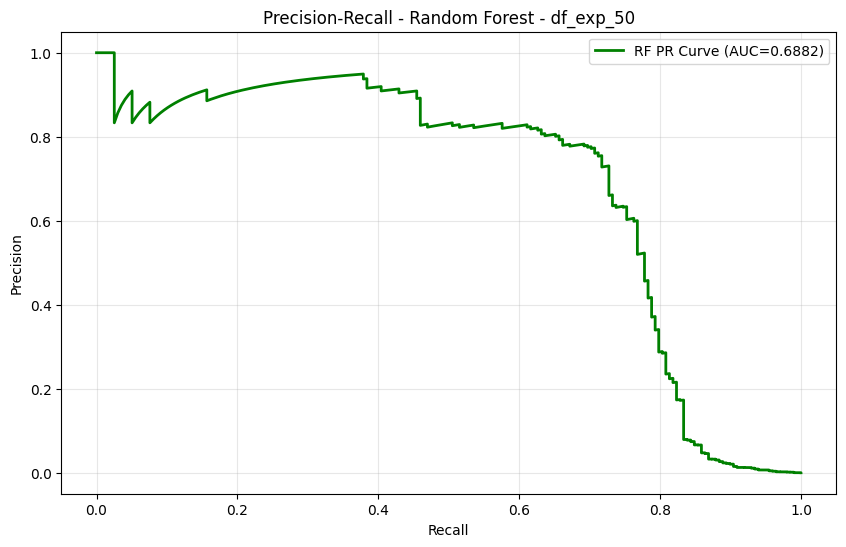

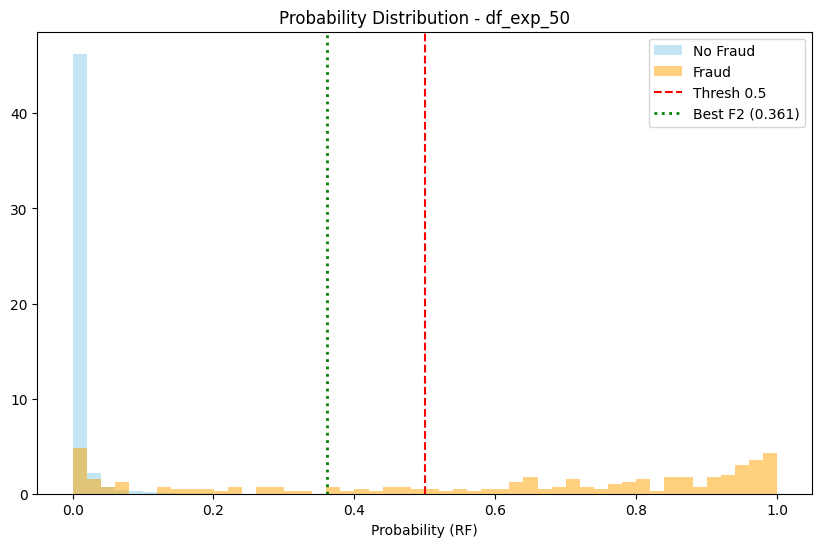


Detailed analysis (Random Forest): df_exp_random
Available PCA variables: 28 -> ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== PCA Variable Correlation Analysis ===
Pairs with correlation >= 0.8: 0
Variables removed: 0
Final variables: 28

--- Confusion Matrix (RF at 0.5) ---
TN: 135122 | FP: 12
FN: 58 | TP: 140
F2 Score: 0.7415
AUC-PR: 0.7816
ROC-AUC: 0.9584

--- Optimal Threshold RF (Max F2) ---
Threshold: 0.3097
F2 Score:  0.7895
Recall:    0.7727 (TP: 153)
Precision: 0.8644 (FP: 24)


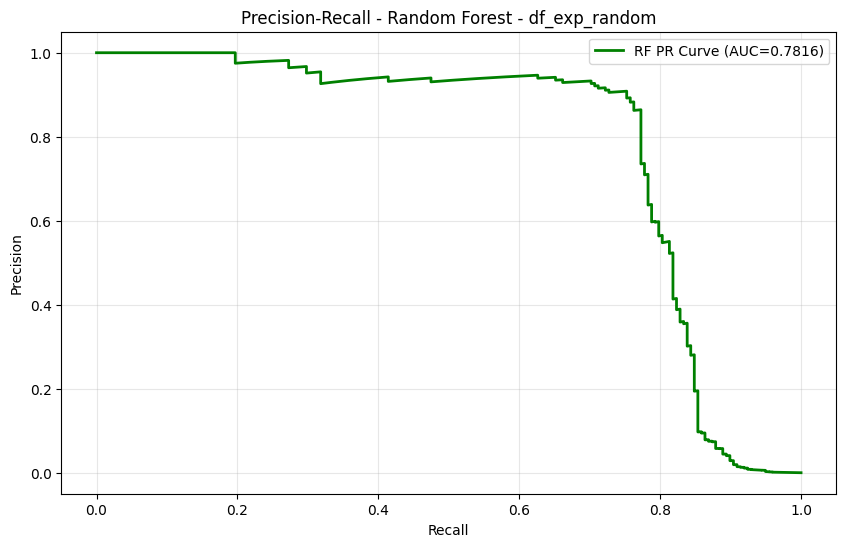

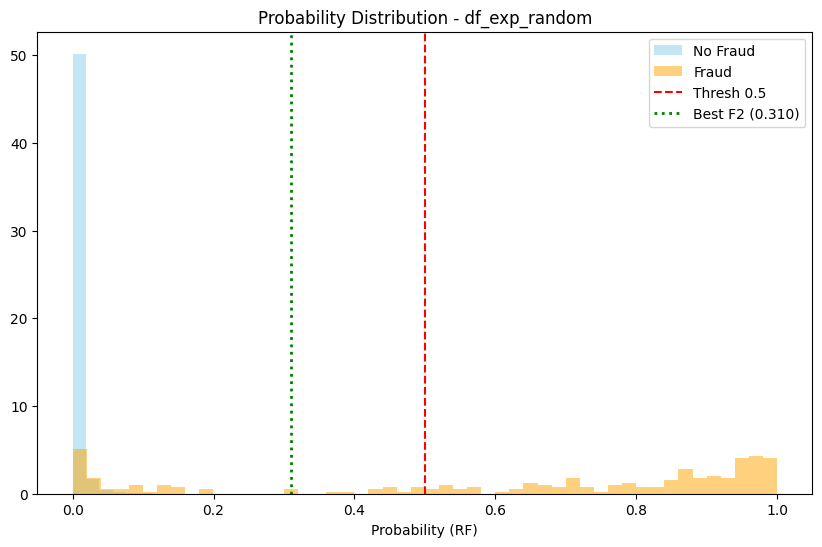


Detailed analysis (Random Forest): df_exp_63
Available PCA variables: 28 -> ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== PCA Variable Correlation Analysis ===
Pairs with correlation >= 0.8: 38
Variables removed: 13
Final variables: 15

--- Confusion Matrix (RF at 0.5) ---
TN: 135103 | FP: 31
FN: 89 | TP: 109
F2 Score: 0.5848
AUC-PR: 0.6165
ROC-AUC: 0.9616

--- Optimal Threshold RF (Max F2) ---
Threshold: 0.3160
F2 Score:  0.7001
Recall:    0.7121 (TP: 141)
Precision: 0.6558 (FP: 74)


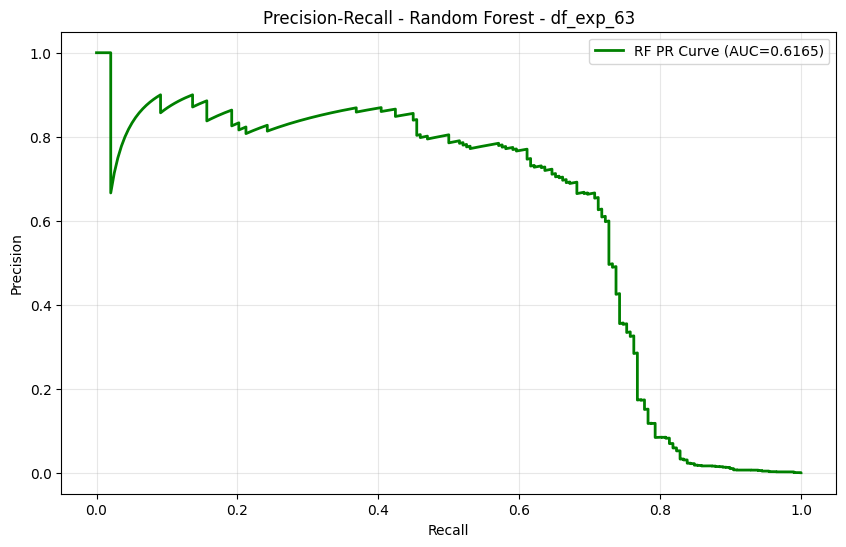

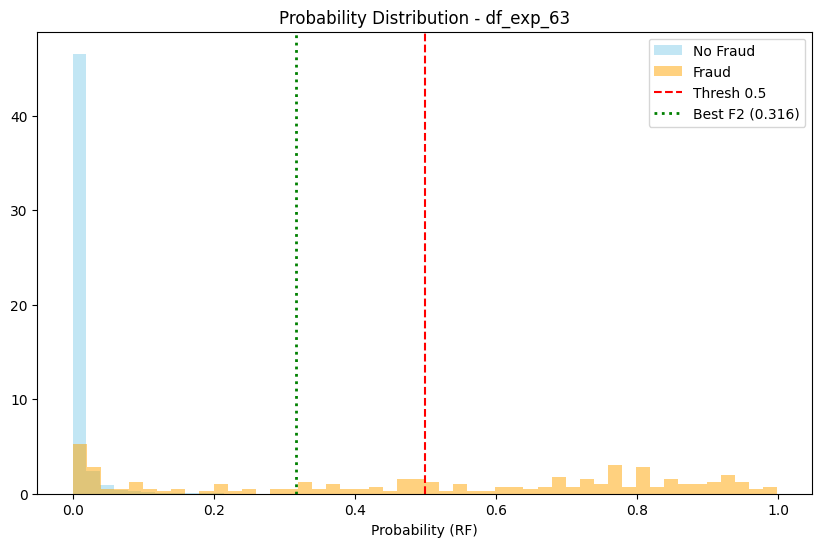


Detailed analysis (Random Forest): df_exp_same_prop
Available PCA variables: 28 -> ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']
Train date: 2023-01-01 | Test date: 2023-01-02

=== PCA Variable Correlation Analysis ===
Pairs with correlation >= 0.8: 0
Variables removed: 0
Final variables: 28

--- Confusion Matrix (RF at 0.5) ---
TN: 135122 | FP: 12
FN: 56 | TP: 142
F2 Score: 0.7505
AUC-PR: 0.7760
ROC-AUC: 0.9646

--- Optimal Threshold RF (Max F2) ---
Threshold: 0.2997
F2 Score:  0.7843
Recall:    0.7677 (TP: 152)
Precision: 0.8588 (FP: 25)


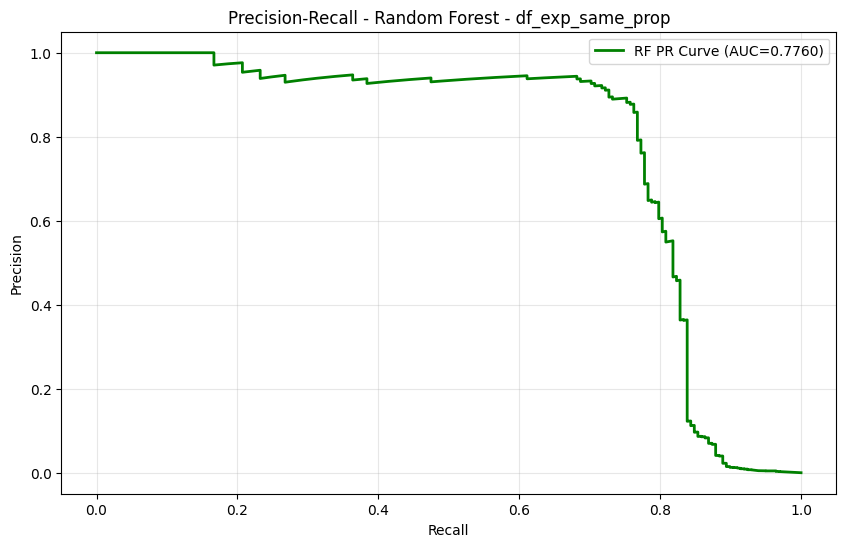

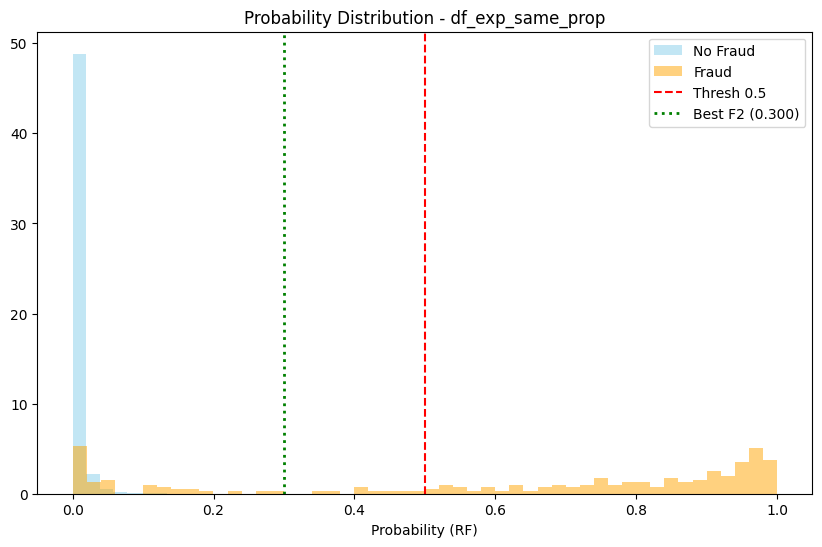


FINAL COMPARATIVE TABLE (Sorted by F2-Score)
         dataset   auc_pr  f2_fraude_opt  recall_at_f2_opt  best_thresh_f2  roc_auc
   df_exp_random 0.781591       0.789474          0.772727        0.309667 0.958376
df_exp_same_prop 0.776049       0.784314          0.767677        0.299719 0.964634
       df_exp_50 0.688162       0.728008          0.727273        0.361349 0.967975
       df_exp_63 0.616465       0.700099          0.712121        0.315988 0.961580


In [12]:
# Path to data files - desde notebooks/ apunta a content/models/
# DATA_PATH should be defined in a previous cell (Cell 4 or Cell 6)
# If not defined, use relative path
if 'DATA_PATH' not in globals():
    from pathlib import Path
    DATA_PATH = Path(__file__).parent.parent / "content" if '__file__' in globals() else Path("../content")

# 1. Define the list of tuples (dataframe, name)
df_exp_50 = pd.read_csv(DATA_PATH / "df_exp_50.csv")
df_exp_random = pd.read_csv(DATA_PATH / "df_exp_random.csv")
df_exp_63 = pd.read_csv(DATA_PATH / "df_exp_63.csv")
df_exp_same_prop = pd.read_csv(DATA_PATH / "df_exp_same_prop.csv")

# NOTE: Comentado - archivos con "_1" al final no se usan
# df_exp_50_1 = pd.read_csv(DATA_PATH / "df_exp_501.csv")
# df_exp_random_1 = pd.read_csv(DATA_PATH / "df_exp_random1.csv")
# df_exp_63_1 = pd.read_csv(DATA_PATH / "df_exp_631.csv")
# df_exp_same_prop_1 = pd.read_csv(DATA_PATH / "df_exp_same_prop1.csv")

datasets_to_evaluate = [
    (df_exp_50, 'df_exp_50'),
    (df_exp_random, 'df_exp_random'),
    (df_exp_63, 'df_exp_63'),
    (df_exp_same_prop, 'df_exp_same_prop'),
    # (df_exp_50_1, 'df_exp_50_1'),
    # (df_exp_random_1, 'df_exp_random_1'),
    # (df_exp_63_1, 'df_exp_63_1'),
    # (df_exp_same_prop_1, 'df_exp_same_prop_1')
]

# 2. List to accumulate results
results_list = []

for df_dataset, name_dataset in datasets_to_evaluate:
  metrics = eval_desbalanceado_rf(df_dataset, name_dataset)

  if metrics:
      results_list.append(metrics)


# Final Comparative Summary
if results_list:
    df_results = pd.DataFrame(results_list)

    # Key columns to show in the summary (prioritizing F2 and Recall)
    cols_to_show = [
        'dataset',
        'auc_pr',
        'f2_fraude_opt',
        'recall_at_f2_opt',
        'best_thresh_f2',
        'f1_fraude_opt',
        'roc_auc'
    ]
    final_cols = [c for c in cols_to_show if c in df_results.columns]

    print("\n" + "="*80)
    print("FINAL COMPARATIVE TABLE (Sorted by F2-Score)")
    print("="*80)

    summary_sorted = df_results[final_cols].sort_values(by='f2_fraude_opt', ascending=False)

    print(summary_sorted.to_string(index=False))

else:
    print("No results generated to show.")

### Would the model improve by adding other variables for the selected dataframe?

In [13]:
df = df_exp_same_prop.copy()
df1 = df_exp_random.copy()

In [14]:
df.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,tx_per_customer,tx_rate,merchant_fraud_rate,country_fraud_rate,geo_anomaly,device_change,browser_change,shared_ip,amount_log,is_outlier_amount
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,...,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,-0.133993,0.029913,0.248294,0.081086,-0.137806,0.025226,-0.080747,0.030543,-0.051725,-0.039541,...,286.991637,0.397490,0.007103,0.006991,0.995890,0.709629,0.619651,0.000086,3.164862,0.113147
std,1.985983,1.677042,1.623938,1.429797,1.421064,1.320563,1.360756,1.322377,1.125260,1.203206,...,16.347788,0.340955,0.065611,0.000373,0.063978,0.453947,0.485483,0.009273,1.666818,0.316773
min,-56.407510,-72.718107,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.226056,-13.434066,-24.588262,...,238.494923,0.122485,-0.002800,0.006382,-0.001769,-0.018217,-0.021917,-0.000393,-0.063959,-0.013237
25%,-0.977104,-0.579382,-0.400939,-0.793279,-0.794556,-0.726776,-0.584137,-0.175996,-0.683204,-0.524643,...,276.000000,0.187766,0.000000,0.006704,1.000000,0.002085,0.000000,0.000000,1.893358,0.000000
50%,-0.105755,0.088492,0.462063,0.068794,-0.177506,-0.235071,-0.010369,0.049230,-0.100097,-0.099827,...,287.000000,0.263507,0.000000,0.006896,1.000000,1.000000,0.999430,0.000000,3.161272,0.000000
75%,1.214317,0.806793,1.198816,0.878394,0.455765,0.422153,0.499732,0.351692,0.551523,0.436780,...,298.000000,0.453287,0.000168,0.007056,1.000000,1.000000,1.000000,0.000000,4.382027,0.001144
max,2.454930,22.057729,9.382558,16.875344,34.814764,73.301626,120.589494,20.027754,15.595433,23.747468,...,335.429424,2.222460,1.001947,0.007613,1.002780,1.021217,1.022647,1.000115,10.153941,1.012866


In [15]:
df1.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,tx_per_customer,tx_rate,merchant_fraud_rate,country_fraud_rate,geo_anomaly,device_change,browser_change,shared_ip,amount_log,is_outlier_amount
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,...,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,-0.133205,0.029190,0.249792,0.081581,-0.140109,0.025836,-0.079665,0.031955,-0.050780,-0.041967,...,287.044285,0.398488,0.007148,0.006991,0.995893,0.709262,0.619349,0.000078,3.168556,0.113695
std,1.981548,1.666091,1.624023,1.430279,1.419320,1.318206,1.358762,1.304650,1.124777,1.201418,...,16.336693,0.342251,0.065975,0.000373,0.063964,0.454104,0.485556,0.008832,1.667375,0.317447
min,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,-24.588262,...,238.587114,0.119721,-0.003229,0.006380,-0.002046,-0.018479,-0.023125,-0.000472,-0.054260,-0.014358
25%,-0.976345,-0.579318,-0.398418,-0.793677,-0.797008,-0.727106,-0.584343,-0.175317,-0.682157,-0.525822,...,276.000000,0.188011,0.000000,0.006703,1.000000,0.002049,0.000000,0.000000,1.902108,0.000000
50%,-0.104026,0.088517,0.463180,0.069159,-0.178903,-0.232838,-0.010055,0.050636,-0.098973,-0.101192,...,287.000000,0.263968,0.000000,0.006894,1.000000,1.000000,0.999387,0.000000,3.166740,0.000000
75%,1.213402,0.804826,1.201748,0.880741,0.455264,0.426814,0.499965,0.352674,0.551743,0.431488,...,298.000000,0.459096,0.000168,0.007056,1.000000,1.000000,1.000000,0.000000,4.386401,0.001141
max,2.454930,22.057729,9.403553,16.875344,34.801666,73.301626,120.589494,20.025763,15.613053,23.757545,...,335.418338,2.222482,1.001846,0.007613,1.002837,1.020570,1.021924,1.000159,10.153941,1.013572


--- Temporal Split ---
Train Date: 2023-01-01
Test Date:  2023-01-02
Train shape: (359451, 66), Test shape: (140549, 66)


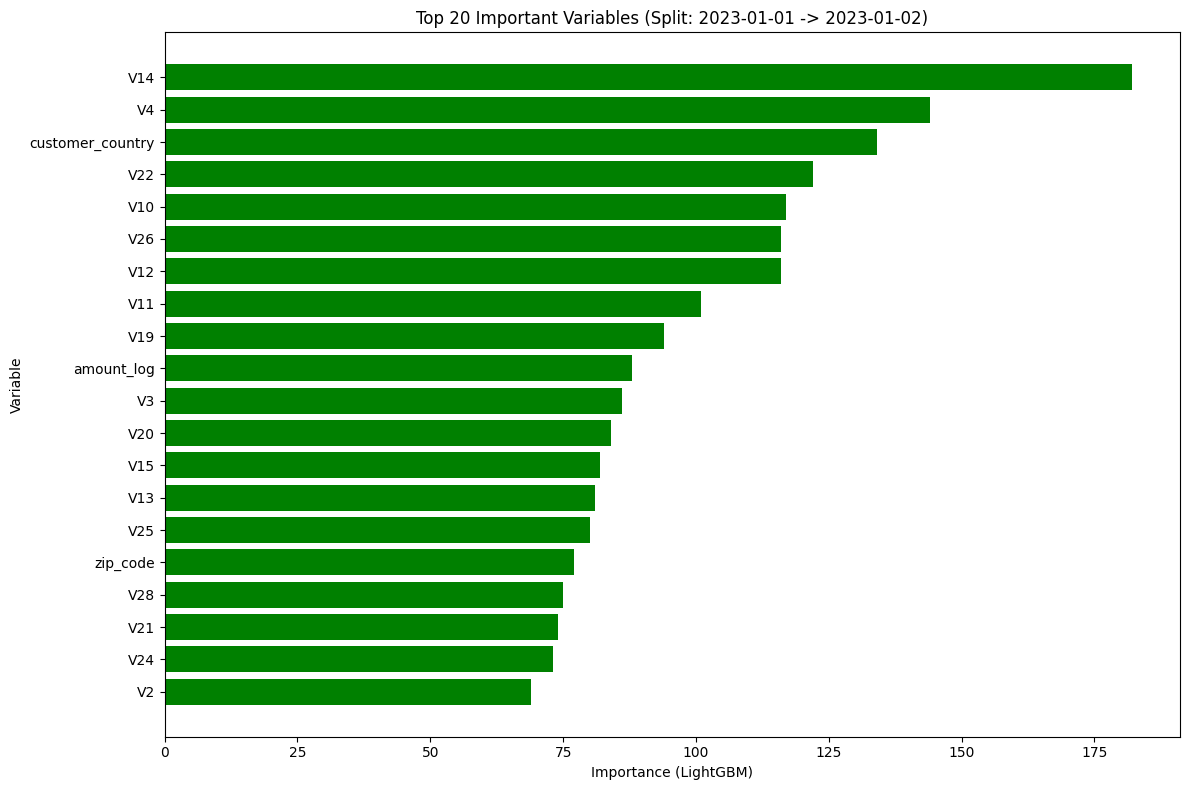

Vars: 1 | F2-score: 0.2259 | Recall: 0.8800 | AUC: 0.9303
Vars: 5 | F2-score: 0.7015 | Recall: 0.7774 | AUC: 0.8994
Vars: 10 | F2-score: 0.7658 | Recall: 0.7821 | AUC: 0.9226
Vars: 15 | F2-score: 0.7207 | Recall: 0.7296 | AUC: 0.8736
Vars: 20 | F2-score: 0.6928 | Recall: 0.7156 | AUC: 0.9005
Vars: 25 | F2-score: 0.6805 | Recall: 0.7378 | AUC: 0.8804
Vars: 30 | F2-score: 0.6694 | Recall: 0.7448 | AUC: 0.9032
Vars: 35 | F2-score: 0.6808 | Recall: 0.7611 | AUC: 0.8973
Vars: 40 | F2-score: 0.6829 | Recall: 0.7424 | AUC: 0.8873


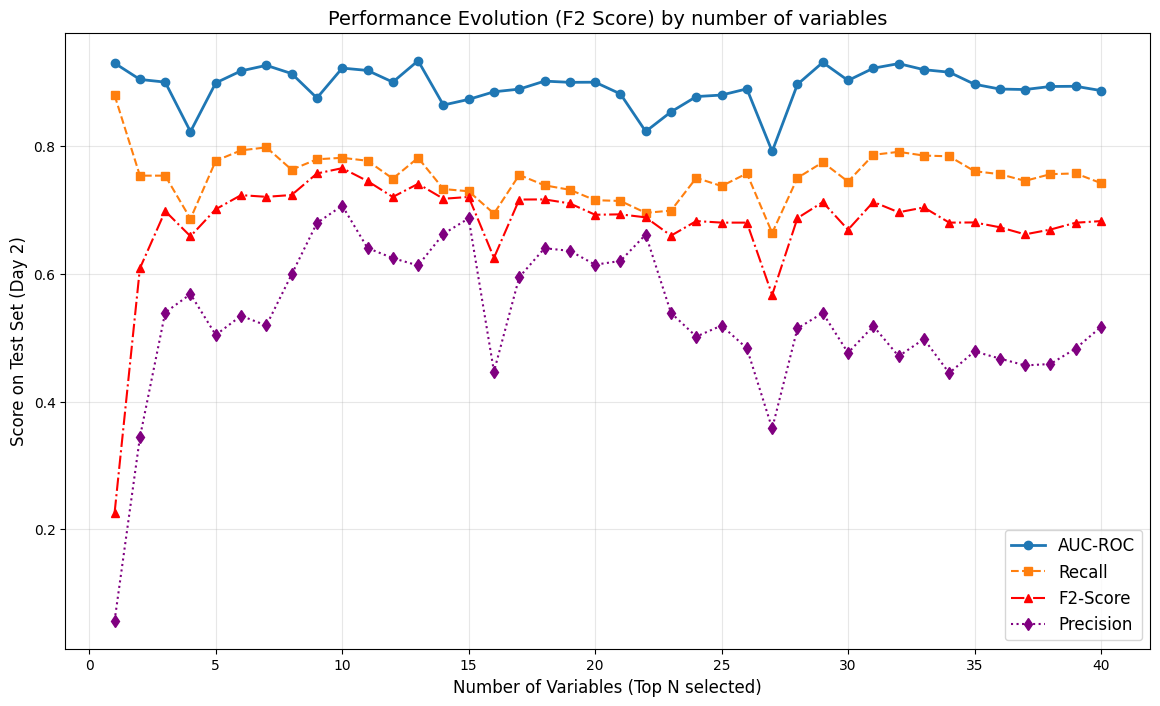

In [16]:
#since datasets are similar, we only do this with one of them
import lightgbm as lgbm
# ============================================================================
# 1. Data Preparation with Temporal Split (Day 1 vs Day 2)
# ============================================================================

df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df['date'] = df['timestamp'].dt.date

# Identify available days
dates = sorted(df['date'].dropna().unique())

if len(dates) < 2:
    raise ValueError("The dataset needs at least 2 different days to perform this split.")

train_date = dates[0]
test_date = dates[1]

print(f"--- Temporal Split ---")
print(f"Train Date: {train_date}")
print(f"Test Date:  {test_date}")

# Create Train and Test DataFrames
train_df = df[df['date'] == train_date].copy()
test_df = df[df['date'] == test_date].copy()

# Define Columns to exclude (including those generated for the split)
TARGET_COLUMN = 'Class'
COLS_TO_EXCLUDE = [
    TARGET_COLUMN, 'transaction_id', 'customer_id', 'device_id',
    'email', 'phone', 'name', 'timestamp', 'date',
    'country_fraud_rate', "merchant_fraud_rate"
]

# Separate X and y
y_train = train_df[TARGET_COLUMN]
X_train = train_df.drop(columns=COLS_TO_EXCLUDE, errors='ignore')

y_test = test_df[TARGET_COLUMN]
X_test = test_df.drop(columns=COLS_TO_EXCLUDE, errors='ignore')

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# Convert categorical variables to 'category' for LightGBM
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

for col in categorical_features:
    X_train[col] = X_train[col].astype('category')
    if col in X_test.columns:
        X_test[col] = X_test[col].astype('category')

# ============================================================================
# 2. Train Base Model to obtain Importance Ranking
# ============================================================================

lgbm_base = lgbm.LGBMClassifier(
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_base.fit(X_train, y_train)

# Create Importance DataFrame
importances = lgbm_base.feature_importances_
importance_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

sorted_features_LGBM = importance_df['Variable'].tolist()

# PLOT 1: Top 20 Feature Importances
top_20_features = importance_df.head(20)

plt.figure(figsize=(12, 8))
plt.barh(
    top_20_features['Variable'],
    top_20_features['Importance'],
    color='green'
)
plt.xlabel("Importance (LightGBM)")
plt.ylabel("Variable")
plt.title(f"Top 20 Important Variables (Split: {train_date} -> {test_date})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ============================================================================
# 3. Iterative Performance Evaluation (F2 Score)
# ============================================================================

metrics_results = {
    'num_vars': [],
    'auc': [],
    'recall': [],
    'f2': [],
    'precision': []
}

# Iterate over sorted features
# We know we won't use more than 40 variables, so we load up to 40
for k in range(1, 41, 1):

    # Select top k variables
    selected_feats = sorted_features_LGBM[:k]

    # Train new model with feature subset
    model_k = lgbm.LGBMClassifier(
        is_unbalance=True,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model_k.fit(X_train[selected_feats], y_train)

    # Predict
    probs_test = model_k.predict_proba(X_test[selected_feats])[:, 1]
    preds_test = model_k.predict(X_test[selected_feats])

    # Calculate Metrics
    metrics_results['num_vars'].append(k)

    try:
        metrics_results['auc'].append(roc_auc_score(y_test, probs_test))
    except:
        metrics_results['auc'].append(0)

    metrics_results['recall'].append(recall_score(y_test, preds_test, zero_division=0))
    metrics_results['precision'].append(precision_score(y_test, preds_test, zero_division=0))

    # --- F2 CALCULATION ---
    # beta=2 prioritizes Recall over Precision
    f2_val = fbeta_score(y_test, preds_test, beta=2, zero_division=0)
    metrics_results['f2'].append(f2_val)

    # Progress Print with F2
    if k % 5 == 0 or k == 1:
        print(f"Vars: {k} | F2-score: {metrics_results['f2'][-1]:.4f} | Recall: {metrics_results['recall'][-1]:.4f} | AUC: {metrics_results['auc'][-1]:.4f}")

# PLOT 2: Performance Curve (With F2)
plt.figure(figsize=(14, 8))

plt.plot(metrics_results['num_vars'], metrics_results['auc'], label='AUC-ROC', marker='o', linewidth=2)
plt.plot(metrics_results['num_vars'], metrics_results['recall'], label='Recall', marker='s', linestyle='--')
# Plotting F2
plt.plot(metrics_results['num_vars'], metrics_results['f2'], label='F2-Score', marker='^', linestyle='-.', color='red')
plt.plot(metrics_results['num_vars'], metrics_results['precision'], label='Precision', marker='d', linestyle=':', color='purple')

plt.xlabel('Number of Variables (Top N selected)', fontsize=12)
plt.ylabel('Score on Test Set (Day 2)', fontsize=12)
plt.title('Performance Evolution (F2 Score) by number of variables', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
print(sorted_features_LGBM)

['V14', 'V4', 'customer_country', 'V22', 'V10', 'V26', 'V12', 'V11', 'V19', 'amount_log', 'V3', 'V20', 'V15', 'V13', 'V25', 'zip_code', 'V28', 'V21', 'V24', 'V2', 'V6', 'hour_sin', 'V7', 'V8', 'V18', 'merchant', 'V9', 'V27', 'V17', 'V23', 'V5', 'hour_cos', 'V16', 'V1', 'days_in_bank_log', 'secs_since_prev_tx', 'city', 'evening', 'credit_score', 'tx_per_customer', 'Amount', 'morning', 'afternoon', 'tx_rate', 'age', 'days_in_bank', 'is_outlier_amount', 'is_mobile', 'device_change', 'is_night_tx', 'main_browser', 'geo_anomaly', 'shared_ip', 'night', 'browser_change', 'is_foreign_tx', 'os', 'ip_address', 'merchant_country', 'is_weekend', 'device_type', 'is_high_amount', 'browser', 'time_of_day', 'tenure_bucket', 'main_device']


Adding the new variables to see how the model improves

In [18]:
variables_pca = [f'V{i}' for i in range(1, 29)]
variables_especificas = [ 'customer_country', 'amount_log', 'timestamp']

In [19]:
VARIABLES_TO_KEEP = list(set(variables_especificas + variables_pca + ['Class']))

In [20]:
print(VARIABLES_TO_KEEP)

['V17', 'V5', 'V23', 'V18', 'V4', 'V10', 'V14', 'V13', 'V16', 'V19', 'V3', 'V15', 'timestamp', 'V24', 'customer_country', 'V1', 'V7', 'V2', 'V27', 'V11', 'V9', 'V12', 'V21', 'V25', 'V22', 'V6', 'amount_log', 'Class', 'V26', 'V8', 'V20', 'V28']


In [21]:
columnas_existentes = [c for c in VARIABLES_TO_KEEP if c in df_exp_same_prop.columns]

In [22]:
df_same_prop_new = df_exp_same_prop[columnas_existentes].copy()
df_random_new = df_exp_random[columnas_existentes].copy()

In [23]:
def eval_desbalanceado_lgbm_all_vars(df_in: pd.DataFrame, name: str) -> dict:
    """
    Evaluates using LIGHTGBM with metrics for extreme imbalance (F2)
    """
    print(f"\n{'='*60}")
    print(f"Detailed analysis (LightGBM - All variables): {name}")
    print(f"{'='*60}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # 0) Date Preparation
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No timestamp found; skipping.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Variable Selection (Pre-encoding cleanup)
    # ---------------------------------------------------------------------

    # Define columns NOT to include in get_dummies (Metadata and Target)
    cols_to_exclude = [
        'Class', 'transaction_id', 'customer_id', 'device_id',
        'email', 'phone', 'name', 'timestamp', 'date'
    ]

    # Filter to drop only those existing in current DF
    vars_to_drop = [c for c in cols_to_exclude if c in df_local.columns]

    # X_raw must only contain predictive variables (numeric or categorical)
    X_raw = df_local.drop(columns=vars_to_drop)
    y_raw = df_local['Class']

    print(f"Variables before encoding: {X_raw.shape[1]}")

    # ---------------------------------------------------------------------
    # 2) Preprocessing: One-Hot Encoding
    # ---------------------------------------------------------------------
    # Apply dummies only to predictive variables
    X_processed = pd.get_dummies(X_raw, drop_first=True)

    print(f"Variables after Encoding: {X_processed.shape[1]}")

    X_processed['date_split_ref'] = df_local['date']

    # ---------------------------------------------------------------------
    # 3) Temporal Split (Day 1 train, Day 2 test)
    # ---------------------------------------------------------------------
    dates = sorted([d for d in X_processed['date_split_ref'].dropna().unique()])
    if len(dates) < 2:
        print("Error: The dataset needs at least 2 different days.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    # Separate Train and Test using the date
    mask_train = X_processed['date_split_ref'] == train_date
    mask_test = X_processed['date_split_ref'] == test_date

    # When creating X_train/X_test, drop the temporal reference column
    X_train = X_processed[mask_train].drop(columns=['date_split_ref'])
    y_train = y_raw[mask_train]

    X_test = X_processed[mask_test].drop(columns=['date_split_ref'])
    y_test = y_raw[mask_test]

    # ---------------------------------------------------------------------
    # 4) Correlation Cleaning
    # ---------------------------------------------------------------------
    print("\n=== Correlation Analysis (All vars) ===")

    corr_matrix = X_train.corr().abs()
    threshold_corr = 0.90

    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > threshold_corr)]

    print(f"Variables removed due to high correlation (> {threshold_corr}): {len(to_drop_corr)}")

    X_train = X_train.drop(columns=to_drop_corr)
    X_test = X_test.drop(columns=to_drop_corr)

    print(f"Final variables for the model: {X_train.shape[1]}")

    # ---------------------------------------------------------------------
    # 5) Train LightGBM
    # ---------------------------------------------------------------------
    model = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    model.fit(X_train, y_train)

    # Predictions
    y_proba = model.predict_proba(X_test)[:, 1]

    # ---------------------------------------------------------------------
    # 6) Metrics and Thresholds
    # ---------------------------------------------------------------------
    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Search for best F2
    scores_list = []
    for prec_th, rec_th, thresh in zip(precision_arr[:-1], recall_arr[:-1], thresholds_pr):
        denom = (4 * prec_th) + rec_th
        f2_val = 5 * (prec_th * rec_th) / denom if denom > 0 else 0.0
        scores_list.append((thresh, prec_th, rec_th, f2_val))

    best_thresh_f2 = 0.5
    best_f2_score = 0.0
    best_rec_f2 = 0.0
    best_prec_f2 = 0.0

    if scores_list:
        best_row = max(scores_list, key=lambda x: x[3])
        best_thresh_f2, best_prec_f2, best_rec_f2, best_f2_score = best_row

    # Recalculate matrix for optimal
    y_pred_opt = (y_proba >= best_thresh_f2).astype(int)
    cm_opt = confusion_matrix(y_test, y_pred_opt)
    tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

    # Base Metrics (0.5)
    y_pred_05 = (y_proba >= 0.5).astype(int)
    cm_05 = confusion_matrix(y_test, y_pred_05)
    tn_05, fp_05, fn_05, tp_05 = cm_05.ravel()
    rec_05 = tp_05 / (tp_05 + fn_05) if (tp_05 + fn_05) > 0 else 0.0
    prec_05 = tp_05 / (tp_05 + fp_05) if (tp_05 + fp_05) > 0 else 0.0
    f2_05 = 5 * (prec_05 * rec_05) / ((4 * prec_05) + rec_05) if ((4 * prec_05) + rec_05) > 0 else 0.0

    print(f"\nAUC-PR:  {auc_pr:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"\n--- Threshold 0.5 ---")
    print(f"Recall: {rec_05:.4f} | F2: {f2_05:.4f}")

    print(f"\n--- Optimal Threshold (Maximizes F2) ---")
    print(f"Threshold: {best_thresh_f2:.4f}")
    print(f"F2 Score:  {best_f2_score:.4f}")
    print(f"Recall:    {best_rec_f2:.4f} (TP: {tp_opt})")
    print(f"Precision: {best_prec_f2:.4f} (FP: {fp_opt})")

    # ---------------------------------------------------------------------
    # 7) Plots
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'PR Curve (AUC={auc_pr:.4f})', color='purple', linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall - LightGBM - {name}')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.hist(y_proba[y_test == 0], bins=50, alpha=0.5, label='No Fraud', density=True, color='skyblue')
    plt.hist(y_proba[y_test == 1], bins=50, alpha=0.5, label='Fraud', density=True, color='orange')
    plt.axvline(x=best_thresh_f2, color='blue', linestyle=':', linewidth=2, label=f'Opt F2 ({best_thresh_f2:.3f})')
    plt.legend()
    plt.show()

    return {
        'dataset': name,
        'model': 'LightGBM_AllVars',
        'roc_auc': roc_auc,
        'auc_pr': auc_pr,
        'f2_fraude_05': f2_05,
        'best_thresh_f2': best_thresh_f2,
        'f2_fraude_opt': best_f2_score,
        'recall_at_f2_opt': best_rec_f2,
        'fraudes_totales': int(y_test.sum())
    }


Detailed analysis (LightGBM - All variables): df_same_prop_new
Variables before encoding: 30
Variables after Encoding: 264
Train date: 2023-01-01 | Test date: 2023-01-02

=== Correlation Analysis (All vars) ===
Variables removed due to high correlation (> 0.9): 0
Final variables for the model: 264

AUC-PR:  0.8575
ROC-AUC: 0.9852

--- Threshold 0.5 ---
Recall: 0.7902 | F2: 0.8135

--- Optimal Threshold (Maximizes F2) ---
Threshold: 0.0453
F2 Score:  0.8244
Recall:    0.8205 (TP: 704)
Precision: 0.8401 (FP: 134)


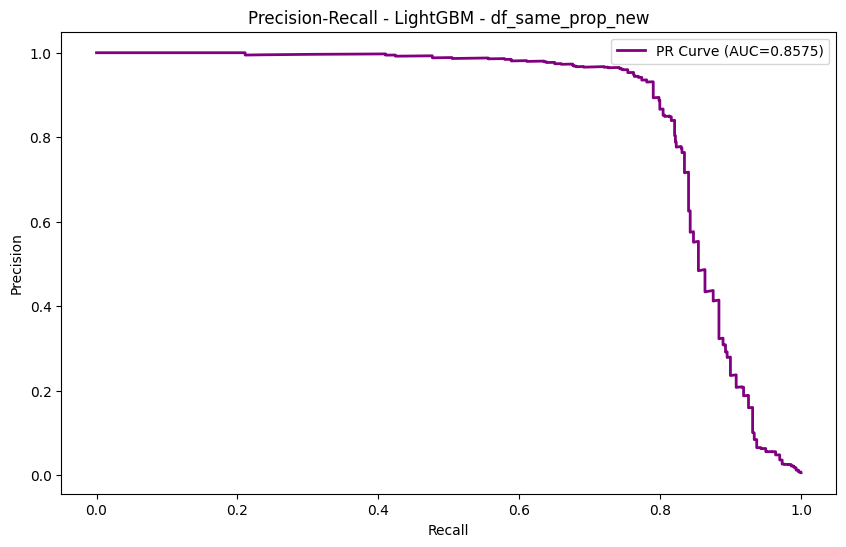

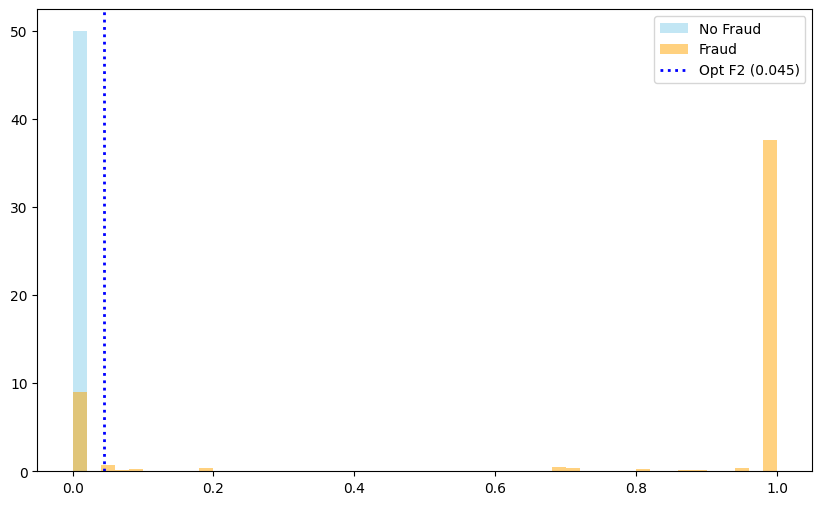

{'dataset': 'df_same_prop_new',
 'model': 'LightGBM_AllVars',
 'roc_auc': 0.9852396746004781,
 'auc_pr': 0.8574881240868932,
 'f2_fraude_05': np.float64(0.8135349172066235),
 'best_thresh_f2': np.float64(0.04528466015203405),
 'f2_fraude_opt': np.float64(0.8243559718969554),
 'recall_at_f2_opt': np.float64(0.8205128205128205),
 'fraudes_totales': 858}

In [24]:
eval_desbalanceado_lgbm_all_vars(df_same_prop_new, "df_same_prop_new")


Detailed analysis (LightGBM - All variables): df_random_new
Variables before encoding: 30
Variables after Encoding: 264
Train date: 2023-01-01 | Test date: 2023-01-02

=== Correlation Analysis (All vars) ===
Variables removed due to high correlation (> 0.9): 0
Final variables for the model: 264

AUC-PR:  0.8538
ROC-AUC: 0.9820

--- Threshold 0.5 ---
Recall: 0.7960 | F2: 0.8189

--- Optimal Threshold (Maximizes F2) ---
Threshold: 0.0834
F2 Score:  0.8302
Recall:    0.8205 (TP: 704)
Precision: 0.8713 (FP: 104)


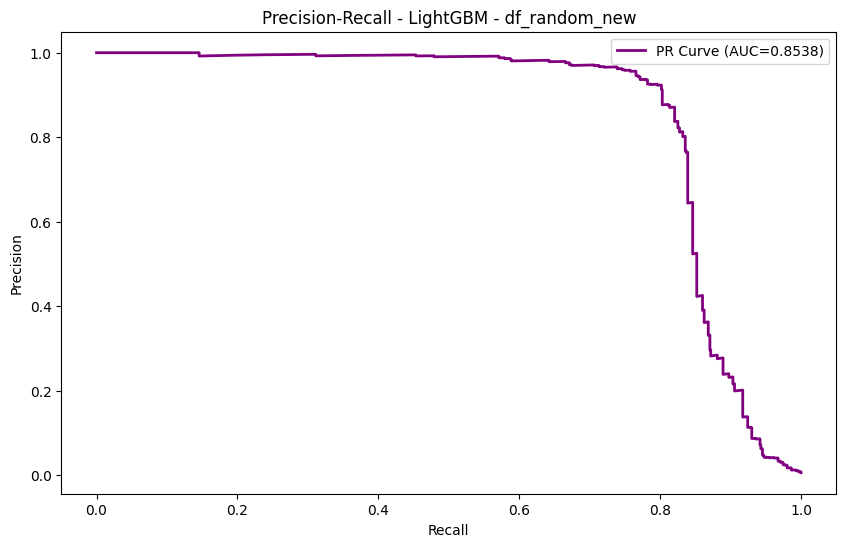

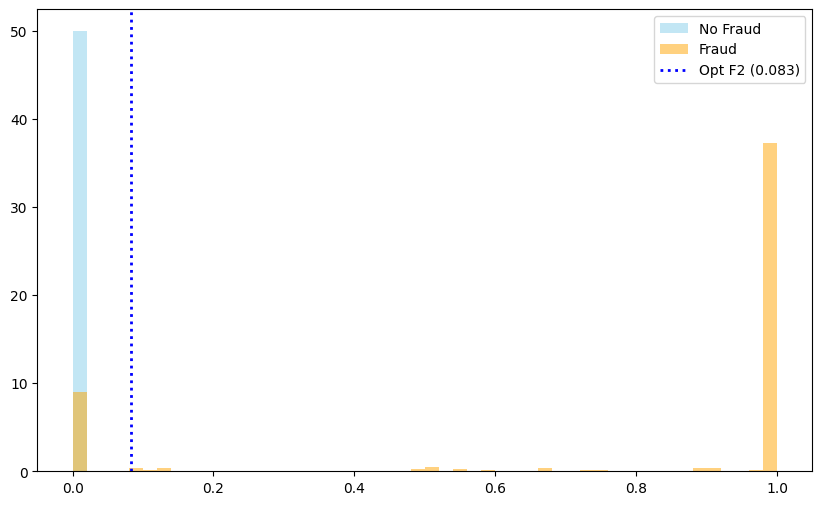

{'dataset': 'df_random_new',
 'model': 'LightGBM_AllVars',
 'roc_auc': 0.9819801994208361,
 'auc_pr': 0.8538135341318441,
 'f2_fraude_05': np.float64(0.8189448441247003),
 'best_thresh_f2': np.float64(0.0834138918925426),
 'f2_fraude_opt': np.float64(0.8301886792452831),
 'recall_at_f2_opt': np.float64(0.8205128205128205),
 'fraudes_totales': 858}

In [25]:
eval_desbalanceado_lgbm_all_vars(df_random_new, "df_random_new")

## Trying more models with the selected dataframe

#### Random Forest

In [26]:
def eval_desbalanceado_rf_all_vars(df_in: pd.DataFrame, name: str) -> dict:
    """
    Evaluates using RANDOM FOREST with metrics for extreme imbalance.
    Saves the trained model to a .pkl file.
    """
    print(f"\n{'='*60}")
    print(f"Detailed analysis (RF - All variables): {name}")
    print(f"{'='*60}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # 0) Date Preparation
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No timestamp found; skipping.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Variable Selection
    # ---------------------------------------------------------------------
    cols_to_exclude = [
        'Class', 'transaction_id', 'customer_id', 'device_id',
        'email', 'phone', 'name', 'timestamp', 'date'
    ]
    vars_to_drop = [c for c in cols_to_exclude if c in df_local.columns]

    X_raw = df_local.drop(columns=vars_to_drop)
    y_raw = df_local['Class']

    print(f"Variables before encoding: {X_raw.shape[1]}")

    # ---------------------------------------------------------------------
    # 2) Preprocessing: One-Hot Encoding
    # ---------------------------------------------------------------------
    X_processed = pd.get_dummies(X_raw, drop_first=True)
    print(f"Variables after Encoding: {X_processed.shape[1]}")

    X_processed['date_split_ref'] = df_local['date']

    # ---------------------------------------------------------------------
    # 3) Temporal Split
    # ---------------------------------------------------------------------
    dates = sorted([d for d in X_processed['date_split_ref'].dropna().unique()])
    if len(dates) < 2:
        print("Error: The dataset needs at least 2 distinct days.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    mask_train = X_processed['date_split_ref'] == train_date
    mask_test = X_processed['date_split_ref'] == test_date

    X_train = X_processed[mask_train].drop(columns=['date_split_ref'])
    y_train = y_raw[mask_train]

    X_test = X_processed[mask_test].drop(columns=['date_split_ref'])
    y_test = y_raw[mask_test]

    # ---------------------------------------------------------------------
    # 4) Correlation Cleaning
    # ---------------------------------------------------------------------
    print("\n=== Correlation Analysis (All vars) ===")
    corr_matrix = X_train.corr().abs()
    threshold_corr = 0.75
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > threshold_corr)]

    X_train = X_train.drop(columns=to_drop_corr)
    X_test = X_test.drop(columns=to_drop_corr)

    print(f"Final variables for the model: {X_train.shape[1]}")

    # ---------------------------------------------------------------------
    # 5) Train Random Forest
    # ---------------------------------------------------------------------
    model = RandomForestClassifier(
        n_estimators=200,
        criterion='gini',
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=0
    )

    model.fit(X_train, y_train)

    # --- SAVE THE MODEL ---
    filename = f"rf_model_{name}.pkl"
    joblib.dump(model, filename)
    print(f"Model saved successfully as: {filename}")
    # ----------------------

    # Predictions
    y_proba = model.predict_proba(X_test)[:, 1]

    # ---------------------------------------------------------------------
    # 6) Metrics and Thresholds
    # ---------------------------------------------------------------------
    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    scores_list = []
    for prec_th, rec_th, thresh in zip(precision_arr[:-1], recall_arr[:-1], thresholds_pr):
        denom = (4 * prec_th) + rec_th
        f2_val = 5 * (prec_th * rec_th) / denom if denom > 0 else 0.0
        scores_list.append((thresh, prec_th, rec_th, f2_val))

    best_thresh_f2, best_prec_f2, best_rec_f2, best_f2_score = 0.5, 0.0, 0.0, 0.0

    if scores_list:
        best_row = max(scores_list, key=lambda x: x[3])
        best_thresh_f2, best_prec_f2, best_rec_f2, best_f2_score = best_row

    y_pred_opt = (y_proba >= best_thresh_f2).astype(int)
    cm_opt = confusion_matrix(y_test, y_pred_opt)
    tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

    # Base Metrics (0.5)
    y_pred_05 = (y_proba >= 0.5).astype(int)
    cm_05 = confusion_matrix(y_test, y_pred_05)
    tn_05, fp_05, fn_05, tp_05 = cm_05.ravel()
    rec_05 = tp_05 / (tp_05 + fn_05) if (tp_05 + fn_05) > 0 else 0.0
    prec_05 = tp_05 / (tp_05 + fp_05) if (tp_05 + fp_05) > 0 else 0.0
    f2_05 = 5 * (prec_05 * rec_05) / ((4 * prec_05) + rec_05) if ((4 * prec_05) + rec_05) > 0 else 0.0

    print(f"\nAUC-PR:  {auc_pr:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"\n--- Threshold 0.5 ---")
    print(f"Recall: {rec_05:.4f} | F2: {f2_05:.4f}")

    print(f"\n--- Optimal Threshold RF (Max F2) ---")
    print(f"Threshold: {best_thresh_f2:.4f}")
    print(f"F2 Score:  {best_f2_score:.4f}")
    print(f"Recall:    {best_rec_f2:.4f} (TP: {tp_opt})")
    print(f"Precision: {best_prec_f2:.4f} (FP: {fp_opt})")

    # ---------------------------------------------------------------------
    # 7) Plots and Importance
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'RF PR Curve (AUC={auc_pr:.4f})', color='green', linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall - Random Forest - {name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False).head(10)

        plt.figure(figsize=(10, 5))
        feat_imp.plot(kind='barh', color='teal')
        plt.title("Top 10 Important Variables (RF)")
        plt.gca().invert_yaxis()
        plt.show()

    return {
        'dataset': name,
        'model': 'RandomForest_AllVars',
        'roc_auc': roc_auc,
        'auc_pr': auc_pr,
        'f2_fraude_05': f2_05,
        'best_thresh_f2': best_thresh_f2,
        'f2_fraude_opt': best_f2_score,
        'recall_at_f2_opt': best_rec_f2,
        'fraudes_totales': int(y_test.sum())
    }


Detailed analysis (RF - All variables): df_same_prop_new
Variables before encoding: 30
Variables after Encoding: 264
Train date: 2023-01-01 | Test date: 2023-01-02

=== Correlation Analysis (All vars) ===
Final variables for the model: 264
Model saved successfully as: rf_model_df_same_prop_new.pkl

AUC-PR:  0.8484
ROC-AUC: 0.9784

--- Threshold 0.5 ---
Recall: 0.6900 | F2: 0.7323

--- Optimal Threshold RF (Max F2) ---
Threshold: 0.2196
F2 Score:  0.8422
Recall:    0.8275 (TP: 710)
Precision: 0.9068 (FP: 73)


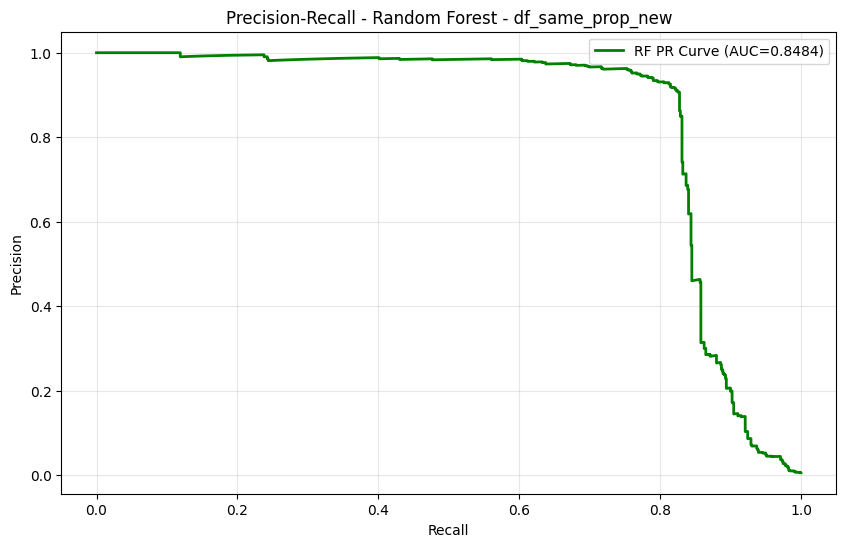

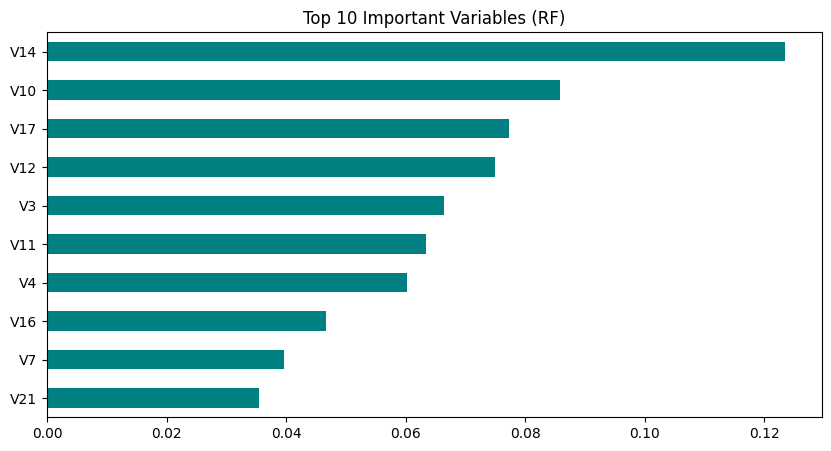

{'dataset': 'df_same_prop_new',
 'model': 'RandomForest_AllVars',
 'roc_auc': 0.9783513859152232,
 'auc_pr': 0.8483859363629195,
 'f2_fraude_05': np.float64(0.7323107372587826),
 'best_thresh_f2': np.float64(0.21960366310682056),
 'f2_fraude_opt': np.float64(0.8422301304863581),
 'recall_at_f2_opt': np.float64(0.8275058275058275),
 'fraudes_totales': 858}

In [27]:
eval_desbalanceado_rf_all_vars(df_same_prop_new, "df_same_prop_new")

#### CatBoost

In [28]:
def eval_desbalanceado_catboost_all_vars(df_in: pd.DataFrame, name: str) -> dict:
    """
    Evaluates using CATBOOST with metrics for extreme imbalance.
    """
    print(f"\n{'='*60}")
    print(f"Detailed analysis (CatBoost - Native): {name}")
    print(f"{'='*60}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # 0) Date Preparation
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No timestamp found; skipping.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Variable Selection
    # ---------------------------------------------------------------------
    cols_to_exclude = [
        'Class', 'transaction_id', 'customer_id', 'device_id',
        'email', 'phone', 'name', 'timestamp', 'date'
    ]

    vars_to_drop = [c for c in cols_to_exclude if c in df_local.columns]

    X_raw = df_local.drop(columns=vars_to_drop)
    y_raw = df_local['Class']

    # ---------------------------------------------------------------------
    # 2) Identification of Categoricals (No One-Hot Encoding)
    # ---------------------------------------------------------------------

    cat_features_indices = []
    cat_features_names = []

    for col in X_raw.columns:
        # If it is object or category, treat it as categorical
        if X_raw[col].dtype == 'object' or X_raw[col].dtype.name == 'category':
            cat_features_names.append(col)
            # Fill categorical nulls to avoid errors
            X_raw[col] = X_raw[col].astype(str).fillna("MISSING")

    print(f"Total variables: {X_raw.shape[1]}")
    print(f"Categorical variables detected: {len(cat_features_names)}")

    # Add temporal reference for the split
    X_raw['date_split_ref'] = df_local['date']

    # ---------------------------------------------------------------------
    # 3) Temporal Split
    # ---------------------------------------------------------------------
    dates = sorted([d for d in X_raw['date_split_ref'].dropna().unique()])
    if len(dates) < 2:
        print("Error: The dataset needs at least 2 different days.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    mask_train = X_raw['date_split_ref'] == train_date
    mask_test = X_raw['date_split_ref'] == test_date

    X_train = X_raw[mask_train].drop(columns=['date_split_ref'])
    y_train = y_raw[mask_train]

    X_test = X_raw[mask_test].drop(columns=['date_split_ref'])
    y_test = y_raw[mask_test]

    # ---------------------------------------------------------------------
    # 4) Correlation Cleaning (Numeric Only)
    # ---------------------------------------------------------------------

    print("\n=== Correlation Analysis (Numeric Variables) ===")

    # Select only numerics for the corr matrix
    X_train_num = X_train.select_dtypes(include=[np.number])

    if not X_train_num.empty:
        corr_matrix = X_train_num.corr().abs()
        threshold_corr = 0.90

        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > threshold_corr)]

        print(f"Numeric variables removed due to high correlation: {len(to_drop_corr)}")

        X_train = X_train.drop(columns=to_drop_corr)
        X_test = X_test.drop(columns=to_drop_corr)

        cat_features_names = [c for c in cat_features_names if c in X_train.columns]
    else:
        print("No numeric variables to analyze for correlation.")

    print(f"Final variables for the model: {X_train.shape[1]}")

    # ---------------------------------------------------------------------
    # 5) Train CatBoost
    # ---------------------------------------------------------------------
    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function='Logloss',
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=0, # Silent
        allow_writing_files=False
    )

    model.fit(X_train, y_train, cat_features=cat_features_names)

    # --- SAVE THE MODEL ---
    filename = f"catboost_model_{name}.pkl"
    joblib.dump(model, filename)
    print(f"Model saved successfully as: {filename}")

    # Predictions
    y_proba = model.predict_proba(X_test)[:, 1]

    # ---------------------------------------------------------------------
    # 6) Metrics and Thresholds
    # ---------------------------------------------------------------------
    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Search for best F2
    scores_list = []
    for prec_th, rec_th, thresh in zip(precision_arr[:-1], recall_arr[:-1], thresholds_pr):
        denom = (4 * prec_th) + rec_th
        f2_val = 5 * (prec_th * rec_th) / denom if denom > 0 else 0.0
        scores_list.append((thresh, prec_th, rec_th, f2_val))

    best_thresh_f2 = 0.5
    best_f2_score = 0.0
    best_rec_f2 = 0.0
    best_prec_f2 = 0.0

    if scores_list:
        best_row = max(scores_list, key=lambda x: x[3])
        best_thresh_f2, best_prec_f2, best_rec_f2, best_f2_score = best_row

    # Optimal Matrix
    y_pred_opt = (y_proba >= best_thresh_f2).astype(int)
    cm_opt = confusion_matrix(y_test, y_pred_opt)
    tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

    # Base Metrics (0.5)
    y_pred_05 = (y_proba >= 0.5).astype(int)
    cm_05 = confusion_matrix(y_test, y_pred_05)
    tn_05, fp_05, fn_05, tp_05 = cm_05.ravel()

    rec_05 = tp_05 / (tp_05 + fn_05) if (tp_05 + fn_05) > 0 else 0.0
    prec_05 = tp_05 / (tp_05 + fp_05) if (tp_05 + fp_05) > 0 else 0.0
    f2_05 = 5 * (prec_05 * rec_05) / ((4 * prec_05) + rec_05) if ((4 * prec_05) + rec_05) > 0 else 0.0

    print(f"\nAUC-PR:  {auc_pr:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    print(f"\n--- Threshold 0.5 ---")
    print(f"Recall: {rec_05:.4f} | Precision: {prec_05:.4f} | F2: {f2_05:.4f}")

    print(f"\n--- Optimal Threshold CatBoost (Max F2) ---")
    print(f"Threshold: {best_thresh_f2:.4f}")
    print(f"F2 Score:  {best_f2_score:.4f}")
    print(f"Recall:    {best_rec_f2:.4f} (TP: {tp_opt})")
    print(f"Precision: {best_prec_f2:.4f} (FP: {fp_opt})")

    # ---------------------------------------------------------------------
    # 7) Plots and Importance
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'CatBoost PR Curve (AUC={auc_pr:.4f})', color='darkorange', linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall - CatBoost - {name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Feature Importance
    importances = model.get_feature_importance()
    feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False).head(10)

    plt.figure(figsize=(10, 5))
    feat_imp.plot(kind='barh', color='brown')
    plt.title("Top 10 Important Variables (CatBoost)")
    plt.gca().invert_yaxis()
    plt.show()

    return {
        'dataset': name,
        'model': 'CatBoost_AllVars',
        'roc_auc': roc_auc,
        'auc_pr': auc_pr,
        'f2_fraude_05': f2_05,
        'best_thresh_f2': best_thresh_f2,
        'f2_fraude_opt': best_f2_score,
        'recall_at_f2_opt': best_rec_f2,
        'fraudes_totales': int(y_test.sum())
    }


Detailed analysis (CatBoost - Native): df_same_prop_new
Total variables: 30
Categorical variables detected: 1
Train date: 2023-01-01 | Test date: 2023-01-02

=== Correlation Analysis (Numeric Variables) ===
Numeric variables removed due to high correlation: 0
Final variables for the model: 30
Model saved successfully as: catboost_model_df_same_prop_new.pkl

AUC-PR:  0.8338
ROC-AUC: 0.9722

--- Threshold 0.5 ---
Recall: 0.8089 | Precision: 0.8875 | F2: 0.8234

--- Optimal Threshold CatBoost (Max F2) ---
Threshold: 0.5546
F2 Score:  0.8260
Recall:    0.8089 (TP: 694)
Precision: 0.9025 (FP: 75)


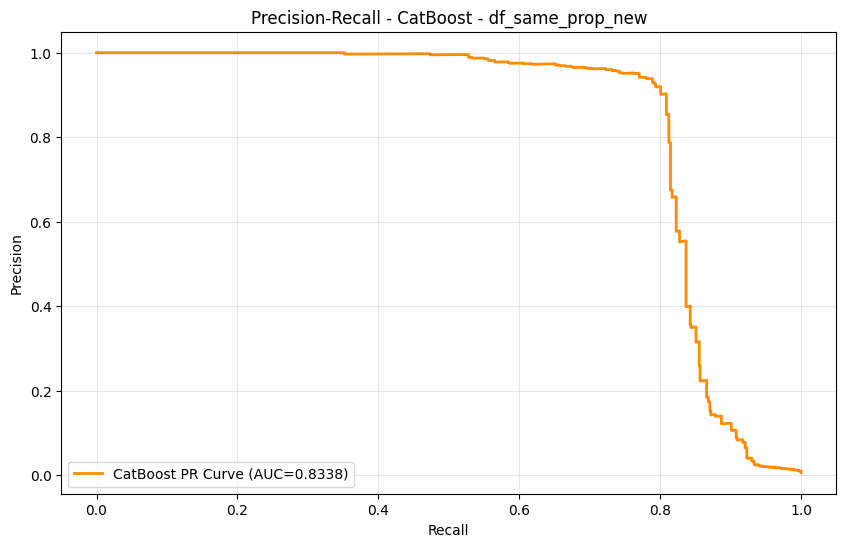

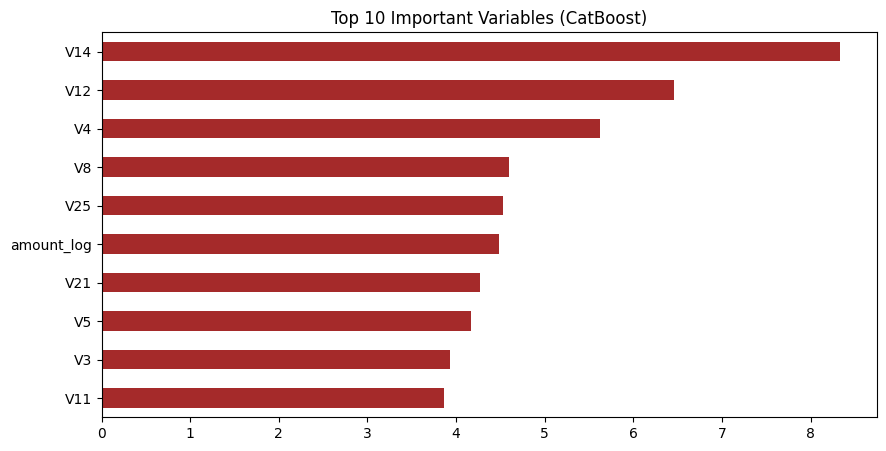

{'dataset': 'df_same_prop_new',
 'model': 'CatBoost_AllVars',
 'roc_auc': 0.9721735147066771,
 'auc_pr': 0.8337853370526674,
 'f2_fraude_05': np.float64(0.8234456573327006),
 'best_thresh_f2': np.float64(0.5545702230283902),
 'f2_fraude_opt': np.float64(0.8259938109973816),
 'recall_at_f2_opt': np.float64(0.8088578088578089),
 'fraudes_totales': 858}

In [29]:
eval_desbalanceado_catboost_all_vars(df_same_prop_new, "df_same_prop_new")

#### Logistic Regression

In [30]:
def eval_desbalanceado_lr_all_vars(df_in: pd.DataFrame, name: str) -> dict:
    """
    Evaluates using LOGISTIC REGRESSION with metrics for extreme imbalance
    """
    print(f"\n{'='*60}")
    print(f"Detailed analysis (Logistic Regression): {name}")
    print(f"{'='*60}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # 0) Date Preparation
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No timestamp found; skipping.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Variable Selection
    # ---------------------------------------------------------------------
    cols_to_exclude = [
        'Class', 'transaction_id', 'customer_id', 'device_id',
        'email', 'phone', 'name', 'timestamp', 'date'
    ]

    vars_to_drop = [c for c in cols_to_exclude if c in df_local.columns]

    X_raw = df_local.drop(columns=vars_to_drop)
    y_raw = df_local['Class']

    print(f"Variables before encoding: {X_raw.shape[1]}")

    # ---------------------------------------------------------------------
    # 2) Encoding
    # ---------------------------------------------------------------------
    X_processed = pd.get_dummies(X_raw, drop_first=True)
    print(f"Variables after Encoding: {X_processed.shape[1]}")
    X_processed['date_split_ref'] = df_local['date']

    # ---------------------------------------------------------------------
    # 3) Temporal Split
    # ---------------------------------------------------------------------
    dates = sorted([d for d in X_processed['date_split_ref'].dropna().unique()])
    if len(dates) < 2:
        print("Error: The dataset needs at least 2 distinct days.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    mask_train = X_processed['date_split_ref'] == train_date
    mask_test = X_processed['date_split_ref'] == test_date

    X_train = X_processed[mask_train].drop(columns=['date_split_ref'])
    y_train = y_raw[mask_train]

    X_test = X_processed[mask_test].drop(columns=['date_split_ref'])
    y_test = y_raw[mask_test]

    # ---------------------------------------------------------------------
    # 4) Correlation Cleaning
    # ---------------------------------------------------------------------
    print("\n=== Correlation Analysis ===")

    corr_matrix = X_train.corr().abs()
    threshold_corr = 0.90

    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > threshold_corr)]

    print(f"Variables removed due to high correlation: {len(to_drop_corr)}")

    X_train = X_train.drop(columns=to_drop_corr)
    X_test = X_test.drop(columns=to_drop_corr)

    # ---------------------------------------------------------------------
    # 5) Scaling
    # ---------------------------------------------------------------------
    print("\nApplying StandardScaler (necessary for LR)...")
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

    print(f"Final variables for the model: {X_train_scaled.shape[1]}")

    # ---------------------------------------------------------------------
    # 6) Train Logistic Regression
    # ---------------------------------------------------------------------
    model = LogisticRegression(
        penalty='l2',
        C=1.0,
        class_weight='balanced',
        solver='lbfgs',
        max_iter=2000,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_scaled, y_train)
    # --- SAVE THE MODEL ---
    filename = f"lr_model_{name}.pkl"
    joblib.dump(model, filename)
    print(f"Model saved successfully as: {filename}")

    # Predictions
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # ---------------------------------------------------------------------
    # 7) Metrics and Thresholds
    # ---------------------------------------------------------------------
    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Search for best F2
    scores_list = []
    for prec_th, rec_th, thresh in zip(precision_arr[:-1], recall_arr[:-1], thresholds_pr):
        denom = (4 * prec_th) + rec_th
        f2_val = 5 * (prec_th * rec_th) / denom if denom > 0 else 0.0
        scores_list.append((thresh, prec_th, rec_th, f2_val))

    best_thresh_f2 = 0.5
    best_f2_score = 0.0
    best_rec_f2 = 0.0
    best_prec_f2 = 0.0

    if scores_list:
        best_row = max(scores_list, key=lambda x: x[3])
        best_thresh_f2, best_prec_f2, best_rec_f2, best_f2_score = best_row

    # Optimal Matrix
    y_pred_opt = (y_proba >= best_thresh_f2).astype(int)
    cm_opt = confusion_matrix(y_test, y_pred_opt)
    tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

    # Base Metrics (0.5)
    y_pred_05 = (y_proba >= 0.5).astype(int)
    cm_05 = confusion_matrix(y_test, y_pred_05)
    tn_05, fp_05, fn_05, tp_05 = cm_05.ravel()
    rec_05 = tp_05 / (tp_05 + fn_05) if (tp_05 + fn_05) > 0 else 0.0
    prec_05 = tp_05 / (tp_05 + fp_05) if (tp_05 + fp_05) > 0 else 0.0
    f2_05 = 5 * (prec_05 * rec_05) / ((4 * prec_05) + rec_05) if ((4 * prec_05) + rec_05) > 0 else 0.0

    print(f"\nAUC-PR:  {auc_pr:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    print(f"\n--- Threshold 0.5 ---")
    print(f"Recall: {rec_05:.4f} | Precision: {prec_05:.4f} | F2: {f2_05:.4f}")

    print(f"\n--- Optimal Threshold LR (Max F2) ---")
    print(f"Threshold: {best_thresh_f2:.4f}")
    print(f"F2 Score:  {best_f2_score:.4f}")
    print(f"Recall:    {best_rec_f2:.4f} (TP: {tp_opt})")
    print(f"Precision: {best_prec_f2:.4f} (FP: {fp_opt})")

    # ---------------------------------------------------------------------
    # 8) Plots and Coefficients
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'LR PR Curve (AUC={auc_pr:.4f})', color='navy', linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall - Logistic Regression - {name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Coefficient Interpretation (Top 10 absolute)
    coeffs = pd.Series(model.coef_[0], index=X_train.columns)

    # Order by absolute magnitude
    top_coeffs = coeffs.abs().sort_values(ascending=False).head(10)
    top_coeffs_original = coeffs.loc[top_coeffs.index]

    colors = ['red' if x < 0 else 'blue' for x in top_coeffs_original]

    plt.figure(figsize=(10, 5))
    top_coeffs_original.plot(kind='barh', color=colors)
    plt.title("Top 10 Coefficients with highest impact")
    plt.xlabel("Coefficient Value (scaled data)")
    plt.axvline(x=0, color='black', linewidth=0.8)
    plt.gca().invert_yaxis()
    plt.show()

    return {
        'dataset': name,
        'model': 'LogisticRegression_AllVars',
        'roc_auc': roc_auc,
        'auc_pr': auc_pr,
        'f2_fraude_05': f2_05,
        'best_thresh_f2': best_thresh_f2,
        'f2_fraude_opt': best_f2_score,
        'recall_at_f2_opt': best_rec_f2,
        'fraudes_totales': int(y_test.sum())
    }


Detailed analysis (Logistic Regression): df_same_prop_new
Variables before encoding: 30
Variables after Encoding: 264
Train date: 2023-01-01 | Test date: 2023-01-02

=== Correlation Analysis ===
Variables removed due to high correlation: 0

Applying StandardScaler (necessary for LR)...
Final variables for the model: 264
Model saved successfully as: lr_model_df_same_prop_new.pkl

AUC-PR:  0.7650
ROC-AUC: 0.9260

--- Threshold 0.5 ---
Recall: 0.8473 | Precision: 0.0983 | F2: 0.3356

--- Optimal Threshold LR (Max F2) ---
Threshold: 0.9981
F2 Score:  0.7636
Recall:    0.7681 (TP: 659)
Precision: 0.7463 (FP: 224)


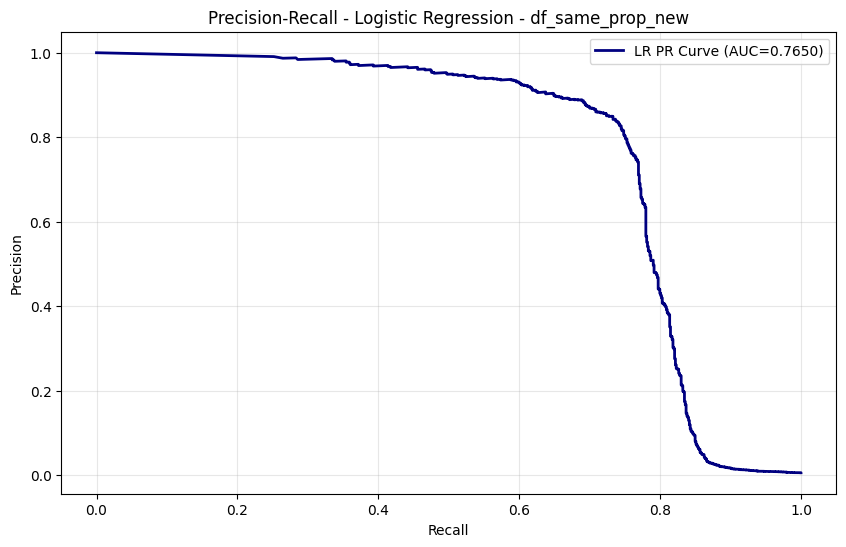

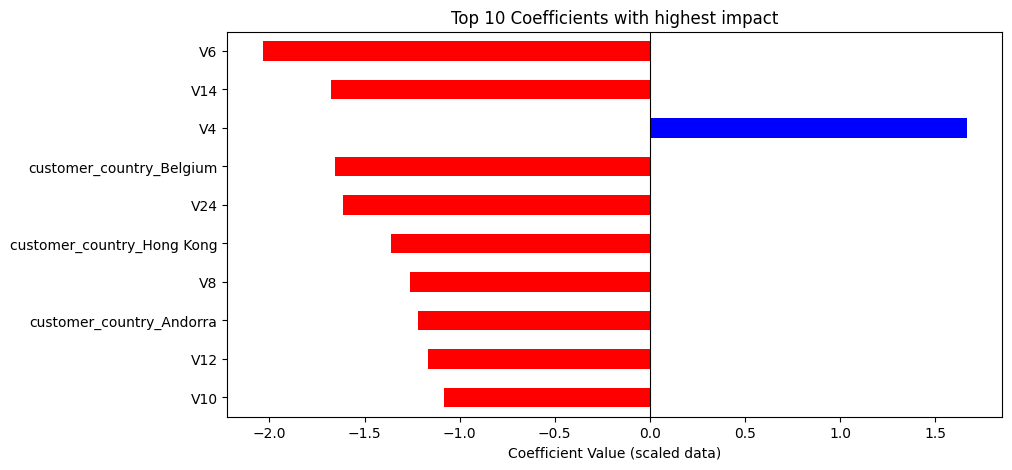

{'dataset': 'df_same_prop_new',
 'model': 'LogisticRegression_AllVars',
 'roc_auc': 0.9259563886919979,
 'auc_pr': 0.7649955860439307,
 'f2_fraude_05': np.float64(0.33564173591874424),
 'best_thresh_f2': np.float64(0.9980503892097669),
 'f2_fraude_opt': np.float64(0.7636152954808807),
 'recall_at_f2_opt': np.float64(0.7680652680652681),
 'fraudes_totales': 858}

In [31]:
eval_desbalanceado_lr_all_vars(df_same_prop_new, "df_same_prop_new")

### Hyperparameter tunning with best model and best df

Best model is random forest



In [32]:
def tune_and_eval_rf(df_in: pd.DataFrame, name: str, n_iter=3) -> dict:
    print(f"\n{'='*80}")
    print(f"Hyperparameter Tuning (RF)")
    print(f"{'='*80}")

    df_local = df_in.copy()

    # ---------------------------------------------------------------------
    # 0) Date Preparation
    # ---------------------------------------------------------------------
    if 'timestamp' not in df_local.columns:
        print("No timestamp found; skipping.")
        return {}

    ts = pd.to_datetime(df_local['timestamp'], errors='coerce')
    df_local['timestamp'] = ts
    df_local['date'] = ts.dt.date

    # ---------------------------------------------------------------------
    # 1) Variable Selection and Encoding
    # ---------------------------------------------------------------------
    cols_to_exclude = [
        'Class', 'transaction_id', 'customer_id', 'device_id',
        'email', 'phone', 'name', 'timestamp', 'date'
    ]
    vars_to_drop = [c for c in cols_to_exclude if c in df_local.columns]

    X_raw = df_local.drop(columns=vars_to_drop)
    y_raw = df_local['Class']

    # One-Hot Encoding
    X_processed = pd.get_dummies(X_raw, drop_first=True)

    # Re-inject date for the split
    X_processed['date_split_ref'] = df_local['date']

    # ---------------------------------------------------------------------
    # 2) Temporal Split
    # ---------------------------------------------------------------------
    dates = sorted([d for d in X_processed['date_split_ref'].dropna().unique()])
    if len(dates) < 2:
        print("Error: At least 2 different days are required for Train/Test.")
        return {}

    train_date, test_date = dates[0], dates[1]
    print(f"Train date: {train_date} | Test date: {test_date}")

    mask_train = X_processed['date_split_ref'] == train_date
    mask_test = X_processed['date_split_ref'] == test_date

    X_train = X_processed[mask_train].drop(columns=['date_split_ref'])
    y_train = y_raw[mask_train]

    X_test = X_processed[mask_test].drop(columns=['date_split_ref'])
    y_test = y_raw[mask_test]

    # ---------------------------------------------------------------------
    # 3) Correlation Cleaning (Train Only)
    # ---------------------------------------------------------------------
    corr_matrix = X_train.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]

    X_train = X_train.drop(columns=to_drop)
    X_test = X_test.drop(columns=to_drop)

    print(f"Final vars: {X_train.shape[1]}")

    # ---------------------------------------------------------------------
    # 4) TUNING Definition (RandomizedSearchCV)
    # ---------------------------------------------------------------------
    f2_scorer = make_scorer(fbeta_score, beta=2)

    # Reduced grid for quick testing
    param_dist = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 10],
        'min_samples_leaf': [1, 4],
        'max_features': ['sqrt', 'log2'],
        'class_weight': ['balanced', 'balanced_subsample']
    }

    rf = RandomForestClassifier(random_state=42, n_jobs=-1)

    # cv=3 * n_iter=3 = 9 total fits
    random_search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring=f2_scorer,
        cv=StratifiedKFold(3),
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    print(f"\nStarting FAST search ({n_iter} iters * 3 folds = {n_iter*3} fits)...")

    random_search.fit(X_train, y_train)

    # --- SAVE THE MODEL ---
    filename = f"rf_hyperparameter_model_{name}.pkl"
    joblib.dump(random_search, filename)
    print(f"Model saved successfully as: {filename}")

    best_model = random_search.best_estimator_
    best_params = random_search.best_params_

    print(f"\nBest parameters found: \n{best_params}")
    print(f"Best F2 Score in CV (Train): {random_search.best_score_:.4f}")

    # ---------------------------------------------------------------------
    # 5) Evaluation
    # ---------------------------------------------------------------------
    y_proba = best_model.predict_proba(X_test)[:, 1]

    precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, y_proba)
    auc_pr = average_precision_score(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)

    scores_list = []
    for prec_th, rec_th, thresh in zip(precision_arr[:-1], recall_arr[:-1], thresholds_pr):
        denom = (4 * prec_th) + rec_th
        f2_val = 5 * (prec_th * rec_th) / denom if denom > 0 else 0.0
        scores_list.append((thresh, f2_val))

    best_row = max(scores_list, key=lambda x: x[1]) if scores_list else (0.5, 0.0)
    best_thresh_f2, best_f2_score = best_row

    y_pred_opt = (y_proba >= best_thresh_f2).astype(int)
    cm_opt = confusion_matrix(y_test, y_pred_opt)
    tn, fp, fn, tp = cm_opt.ravel()

    recall_opt = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec_opt = tp / (tp + fp) if (tp + fp) > 0 else 0

    print(f"\n--- TEST Results (Best Model) ---")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"AUC-PR:  {auc_pr:.4f}")
    print(f"Optimal Threshold: {best_thresh_f2:.4f}")
    print(f"F2 Score (Test):  {best_f2_score:.4f}")
    print(f"Recall (Test):    {recall_opt:.4f}")
    print(f"Precision (Test): {prec_opt:.4f}")

    # ---------------------------------------------------------------------
    # 6) Plots
    # ---------------------------------------------------------------------
    plt.figure(figsize=(10, 6))
    plt.plot(recall_arr, precision_arr, label=f'Best RF (AUC={auc_pr:.4f})', color='purple', linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'PR Curve - Tuned Random Forest - {name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    importances = best_model.feature_importances_
    feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False).head(10)

    plt.figure(figsize=(10, 5))
    feat_imp.plot(kind='barh', color='indigo')
    plt.title("Top 10 Important Variables (Tuned RF)")
    plt.gca().invert_yaxis()
    plt.show()

    return {
        'model': best_model,
        'best_params': best_params,
        'roc_auc': roc_auc,
        'f2_score': best_f2_score,
        'best_thresh': best_thresh_f2
    }


Hyperparameter Tuning (RF)
Train date: 2023-01-01 | Test date: 2023-01-02
Final vars: 264

Starting FAST search (3 iters * 3 folds = 9 fits)...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Model saved successfully as: rf_hyperparameter_model_df_same_prop_new.pkl

Best parameters found: 
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 20, 'class_weight': 'balanced_subsample'}
Best F2 Score in CV (Train): 0.9591

--- TEST Results (Best Model) ---
ROC-AUC: 0.9822
AUC-PR:  0.8455
Optimal Threshold: 0.2794
F2 Score (Test):  0.8341
Recall (Test):    0.8287
Precision (Test): 0.8566


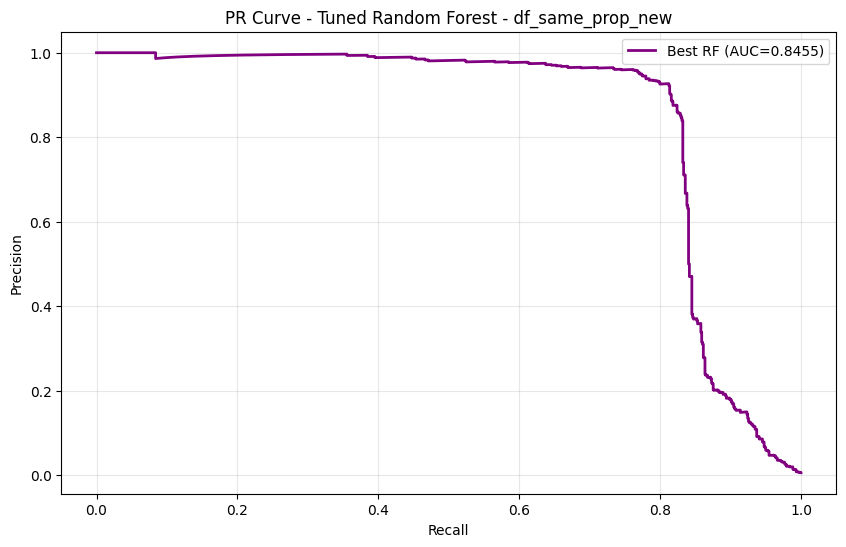

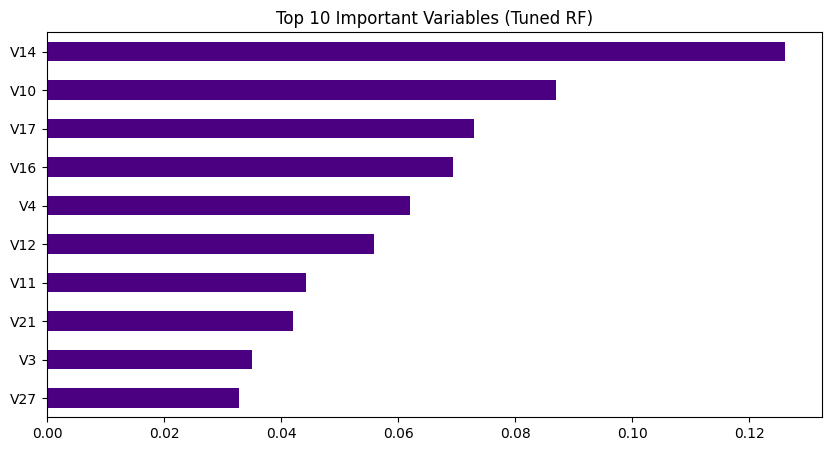

In [33]:
results = tune_and_eval_rf(df_same_prop_new, "df_same_prop_new", n_iter=3)

We keep the predefined hyperparameters since this does not improve